# Unsupervised Flood Risk Zone Identification Using EM-DAT Global Disaster Database

**Abstract**

This notebook extends the comparative clustering framework from the companion paper by replacing the synthetic Kaggle dataset with real-world flood event records from the Emergency Events Database (EM-DAT), the most authoritative global disaster database maintained by CRED (Centre for Research on the Epidemiology of Disasters). Two EM-DAT exports are merged: a historical archive (1900–2026) and a current dataset (2000–2026), yielding 6,193 unique flood events worldwide. Feature engineering derives 11 impact and temporal dimensions from raw EM-DAT fields. All four clustering algorithms — K-Means, Gaussian Mixture Model (GMM), DBSCAN, and OPTICS — are applied with systematic hyperparameter tuning and evaluated via a six-metric framework, directly mirroring the methodology of the companion paper.

**Data Sources:**
- EM-DAT Historical: `public_emdat_incl_hist_2026-06-22.xlsx`
- EM-DAT Current: `public_emdat_2026-06-22.xlsx`
- Source: https://www.emdat.be/ (CRED, UCLouvain, Belgium)

**Keywords:** flood risk clustering, EM-DAT, unsupervised learning, K-Means, GMM, DBSCAN, OPTICS, disaster management


# Table of Contents

1. Reproducibility & Imports
2. Data Loading
3. Dataset Overview
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Data Scaling
8. Principal Component Analysis (PCA)
9. Hyperparameter Tuning
10. Clustering Algorithms
11. Cluster Evaluation
12. Cluster Profiling
13. Statistical Analysis
14. Discussion
15. Conclusion
16. References

## 1. Reproducibility & Imports

In [113]:
# ── Reproducibility: fix all random seeds ──────────────────────────────────────
import os, random, warnings
SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")

import numpy as np
np.random.seed(SEED)

# ── Core imports ───────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
PALETTE = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800", "#00BCD4", "#795548"]

# ── Environment versions ───────────────────────────────────────────────────────
import sklearn, scipy
print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
print(f"sklearn   : {sklearn.__version__}")
print(f"scipy     : {scipy.__version__}")
print(f"Random seed fixed at: {SEED}")

pandas    : 2.3.3
numpy     : 2.3.5
sklearn   : 1.8.0
scipy     : 1.16.3
Random seed fixed at: 42


## 2. Data Loading & Merging

Two EM-DAT exports are loaded and merged. The historical file covers 1900–2026; the current file covers 2000–2026. Deduplication is performed on `DisNo.` (unique EM-DAT event identifier) to avoid double-counting events present in both files.

In [114]:
import subprocess
subprocess.run(["pip", "install", "openpyxl"], check=True)

CompletedProcess(args=['pip', 'install', 'openpyxl'], returncode=0)

In [115]:
# ── Update these paths if needed ───────────────────────────────────────────────
PATH_HIST = r"D:\Flood_Prediction\Flood-Risk-Clustering-EMDAT\public_emdat_2026-06-22.xlsx"  # Historical archive
PATH_CURR = r"D:\Flood_Prediction\Flood-Risk-Clustering-EMDAT\public_emdat_2026-06-22.xlsx"            # Current dataset

# ── Load both files ────────────────────────────────────────────────────────────
df_hist = pd.read_excel(PATH_HIST)
df_curr = pd.read_excel(PATH_CURR)

print(f"Historical dataset : {df_hist.shape[0]:,} rows × {df_hist.shape[1]} columns")
print(f"Current dataset    : {df_curr.shape[0]:,} rows × {df_curr.shape[1]} columns")

# ── Merge and deduplicate ──────────────────────────────────────────────────────
df_all = pd.concat([df_hist, df_curr], ignore_index=True)
df_all = df_all.drop_duplicates(subset=['DisNo.']).reset_index(drop=True)
print(f"\nCombined (deduplicated) : {df_all.shape[0]:,} rows")

# ── Filter: Flood events only ──────────────────────────────────────────────────
df = df_all[df_all['Disaster Type'] == 'Flood'].copy()
df = df.reset_index(drop=True)
print(f"Flood events only       : {len(df):,} records")
print(f"Year range              : {df['Start Year'].min():.0f} – {df['Start Year'].max():.0f}")
print(f"\nFlood subtypes:")
print(df['Disaster Subtype'].value_counts())
print(f"\nRegions:")
print(df['Region'].value_counts())

Historical dataset : 16,853 rows × 47 columns
Current dataset    : 16,853 rows × 47 columns

Combined (deduplicated) : 16,853 rows
Flood events only       : 4,273 records
Year range              : 2000 – 2026

Flood subtypes:
Disaster Subtype
Riverine flood     2032
Flood (General)    1436
Flash flood         763
Coastal flood        42
Name: count, dtype: int64

Regions:
Region
Asia        1733
Africa      1025
Americas     918
Europe       493
Oceania      104
Name: count, dtype: int64


In [116]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Total Flood Events : {len(df):,}")

if 'Country' in df.columns:
    print(f"Countries          : {df['Country'].nunique()}")

if 'Region' in df.columns:
    print(f"Regions            : {df['Region'].nunique()}")

if 'Start Year' in df.columns:
    print(f"Years Covered      : {df['Start Year'].min()} - {df['Start Year'].max()}")

print(f"Features           : {df.shape[1]}")

DATASET SUMMARY
Total Flood Events : 4,273
Countries          : 181
Regions            : 5
Years Covered      : 2000 - 2026
Features           : 47


In [117]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("Missing Values")
    display(missing.to_frame("Count"))
else:
    print("No Missing Values Found")

Missing Values


,Count
Event Name,4262
Reconstruction Costs ('000 US$),4259
"Reconstruction Costs, Adjusted ('000 US$)",4259
Insured Damage ('000 US$),4102
"Insured Damage, Adjusted ('000 US$)",4102
AID Contribution ('000 US$),4017
No. Homeless,3768
No. Injured,3406
Latitude,3267
Longitude,3267


In [118]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


## 3. Feature Engineering

Raw EM-DAT fields are transformed into 11 engineered features suitable for clustering. Unlike the Kaggle dataset (20 ordinal risk-indicator scores), EM-DAT records actual disaster outcomes. Feature engineering therefore focuses on:

1. **Impact severity** — log-transformed death toll, affected population, economic damage
2. **Event duration** — days between start and end date
3. **Temporal context** — decade and seasonality (start month)
4. **Flood type encoding** — one-hot or ordinal encoding of subtype
5. **Geographic encoding** — region as ordinal label
6. **Damage-to-deaths ratio** — proxy for event lethality vs. economic exposure

## Why These Features?

The selected variables capture different dimensions of flood severity.

| Feature | Purpose |
|----------|----------|
| Total Deaths | Measures human fatalities |
| Total Affected | Measures affected population |
| Total Damage | Represents economic losses |
| Duration | Indicates flood persistence |
| Damage per Death | Economic impact per casualty |
| Decade | Captures temporal trends |
| Region Code | Represents geographical characteristics |

These variables collectively describe the social, economic, temporal, and spatial characteristics of flood events.

In [119]:
# ── 3.1 Duration feature ───────────────────────────────────────────────────────
def safe_duration(row):
    """Compute event duration in days; return NaN if any date component is missing."""
    try:
        start = pd.Timestamp(year=int(row['Start Year']),
                             month=int(row['Start Month']),
                             day=int(row['Start Day']))
        end   = pd.Timestamp(year=int(row['End Year']),
                             month=int(row['End Month']),
                             day=int(row['End Day']))
        return max(0, (end - start).days)
    except Exception:
        return np.nan

df['Duration_Days'] = df.apply(safe_duration, axis=1)

# ── 3.2 Log-transformed impact variables ──────────────────────────────────────
# Add 1 before log to handle zeros
df['Log_TotalDeaths']    = np.log1p(df['Total Deaths'].fillna(0))
df['Log_TotalAffected']  = np.log1p(df['Total Affected'].fillna(0))
df['Log_TotalDamage']    = np.log1p(df["Total Damage ('000 US$)"].fillna(0))
df['Log_AdjDamage']      = np.log1p(df["Total Damage, Adjusted ('000 US$)"].fillna(0))

# ── 3.3 Damage-per-death ratio (lethality vs economic exposure proxy) ──────────
# High damage + low deaths → economic event; high deaths + low damage → vulnerable population
total_deaths_safe = df['Total Deaths'].fillna(0) + 1
total_damage_safe = df["Total Damage ('000 US$)"].fillna(0) + 1
df['Log_DamagePerDeath'] = np.log1p(total_damage_safe / total_deaths_safe)

# ── 3.4 Temporal features ──────────────────────────────────────────────────────
df['Decade'] = (df['Start Year'] // 10) * 10  # 1900, 1910, … 2020
df['Start_Month'] = df['Start Month'].fillna(df['Start Month'].median())

# Cyclical encoding of month (captures Jan ≈ Dec proximity)
df['Month_Sin'] = np.sin(2 * np.pi * df['Start_Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Start_Month'] / 12)

# ── 3.5 Categorical encodings ─────────────────────────────────────────────────
# Flood subtype: Riverine=3, General=2, Flash=1, Coastal=0 (severity proxy)
subtype_map = {'Riverine flood': 3, 'Flood (General)': 2,
               'Flash flood': 1, 'Coastal flood': 0}
df['FloodSubtype_Code'] = df['Disaster Subtype'].map(subtype_map).fillna(2)

# Region as ordinal label
le = LabelEncoder()
df['Region_Code'] = le.fit_transform(df['Region'].fillna('Unknown'))
region_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Region encoding:", region_mapping)

# ── 3.6 Duration: fill missing with median ─────────────────────────────────────
df['Duration_Days'] = df['Duration_Days'].fillna(df['Duration_Days'].median())
df['Log_Duration']  = np.log1p(df['Duration_Days'])

# ── 3.7 Define final feature set ──────────────────────────────────────────────
FEATURES = [
    'Log_TotalDeaths',       # Human toll (log scale)
    'Log_TotalAffected',     # Population impact (log scale)
    'Log_TotalDamage',       # Economic loss (log scale)
    'Log_AdjDamage',         # CPI-adjusted economic loss (log scale)
    'Log_DamagePerDeath',    # Lethality vs economic exposure ratio
    'Log_Duration',          # Event duration (log scale)
    'Month_Sin',             # Seasonality — cyclical sine
    'Month_Cos',             # Seasonality — cyclical cosine
    'FloodSubtype_Code',     # Flood type ordinal (0–3)
    'Region_Code',           # Geographic region
    'Start Year',            # Year for temporal trends
]

print(f"\nFinal feature set ({len(FEATURES)} features):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

# ── Drop rows where all key impact features are zero (no data events) ──────────
key_cols = ['Log_TotalDeaths', 'Log_TotalAffected', 'Log_TotalDamage']
mask_all_zero = (df[key_cols] == 0).all(axis=1)
df_model = df[~mask_all_zero][FEATURES].dropna().reset_index(drop=True)
print(f"\nRecords after filtering no-data events : {len(df_model):,}")

Region encoding: {'Africa': np.int64(0), 'Americas': np.int64(1), 'Asia': np.int64(2), 'Europe': np.int64(3), 'Oceania': np.int64(4)}

Final feature set (11 features):
   1. Log_TotalDeaths
   2. Log_TotalAffected
   3. Log_TotalDamage
   4. Log_AdjDamage
   5. Log_DamagePerDeath
   6. Log_Duration
   7. Month_Sin
   8. Month_Cos
   9. FloodSubtype_Code
  10. Region_Code
  11. Start Year

Records after filtering no-data events : 4,207


## 4. Exploratory Data Analysis

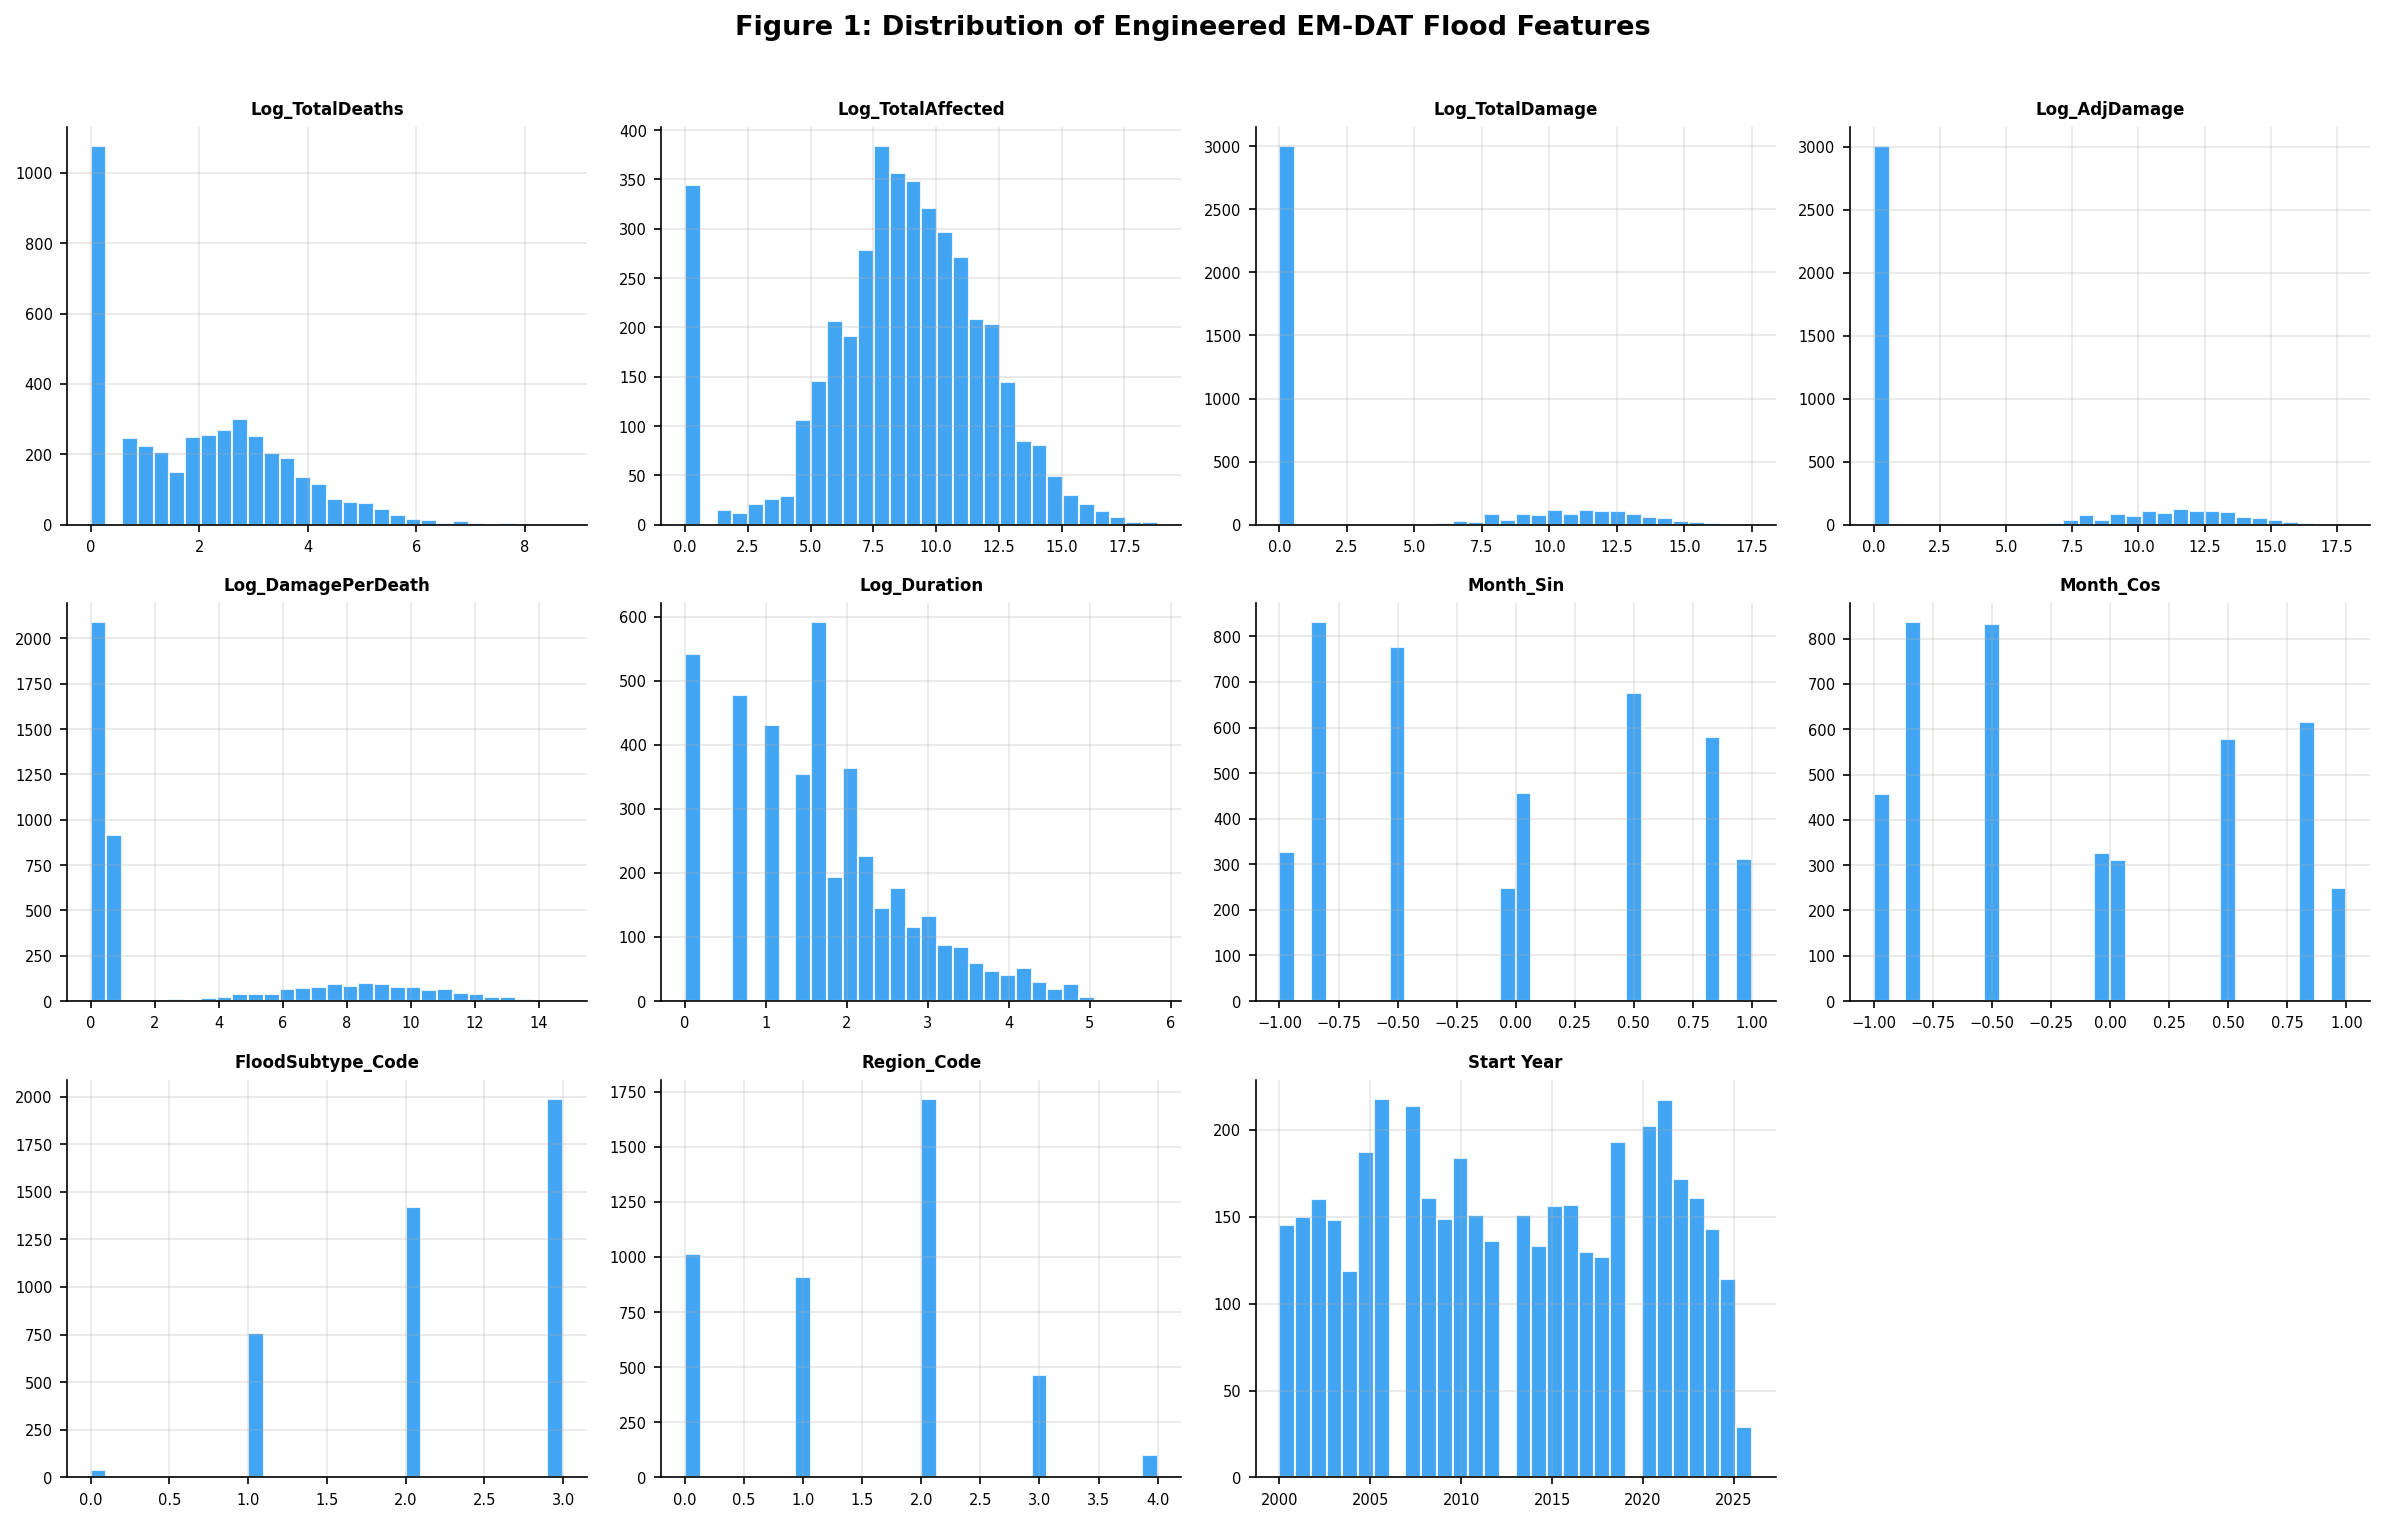

Figure 1 saved.


In [120]:
# ── 4.1 Feature Distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df_model[feat], bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=7)
# Hide unused axes
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Figure 1: Distribution of Engineered EM-DAT Flood Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_emdat_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 1 saved.")

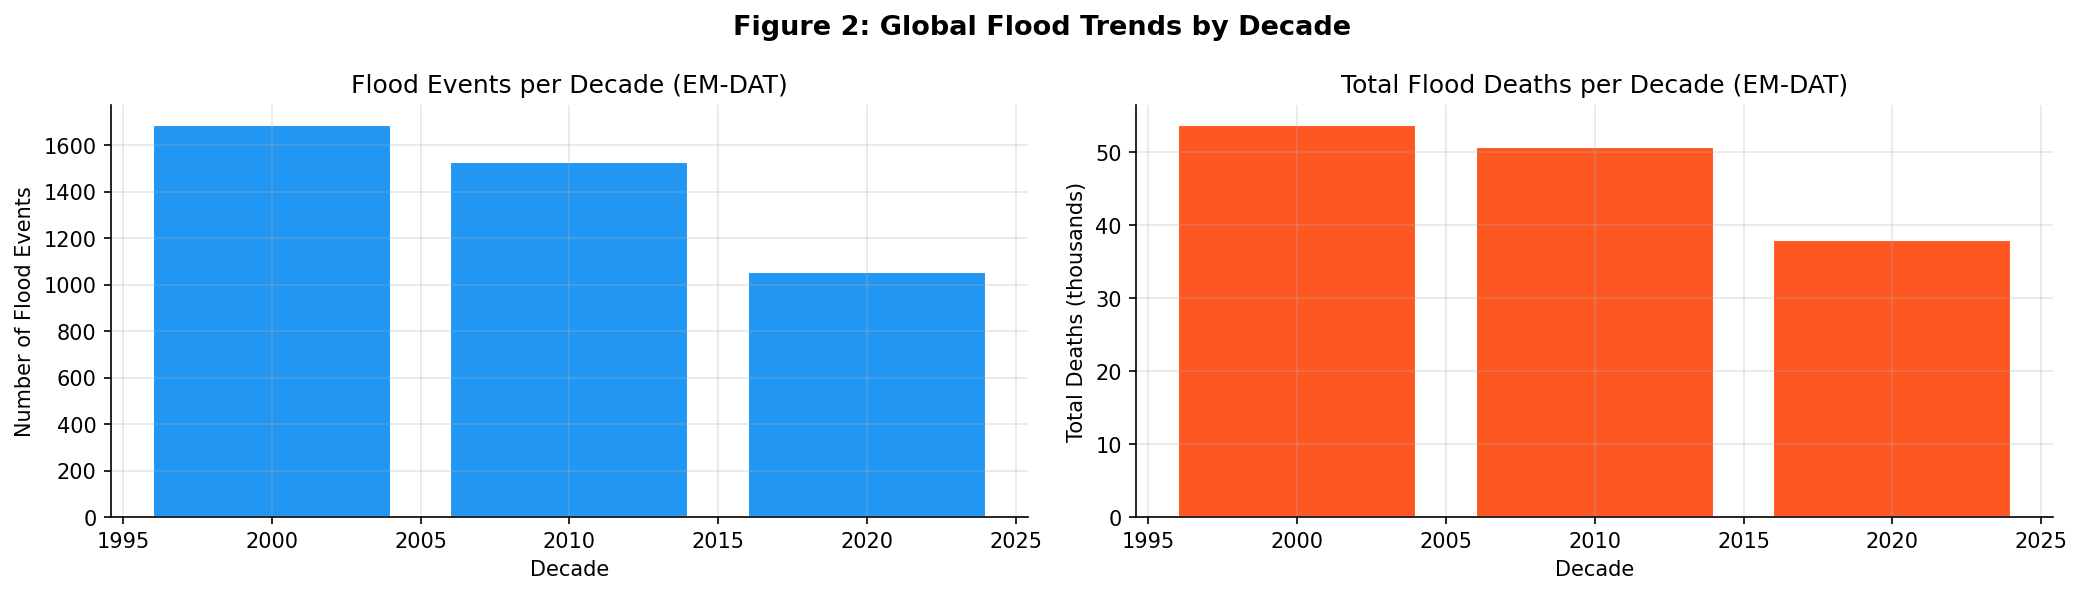

Figure 2 saved.


In [121]:
# ── 4.2 Temporal Trend: flood events per decade ────────────────────────────────
flood_by_decade = df.groupby('Decade').size().reset_index(name='Count')
deaths_by_decade = df.groupby('Decade')['Total Deaths'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(flood_by_decade['Decade'], flood_by_decade['Count'],
            color=PALETTE[0], edgecolor='white', width=8)
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Number of Flood Events')
axes[0].set_title('Flood Events per Decade (EM-DAT)')

axes[1].bar(deaths_by_decade['Decade'], deaths_by_decade['Total Deaths'] / 1e3,
            color=PALETTE[1], edgecolor='white', width=8)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Total Deaths (thousands)')
axes[1].set_title('Total Flood Deaths per Decade (EM-DAT)')

plt.suptitle('Figure 2: Global Flood Trends by Decade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_emdat_temporal_trends.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 2 saved.")

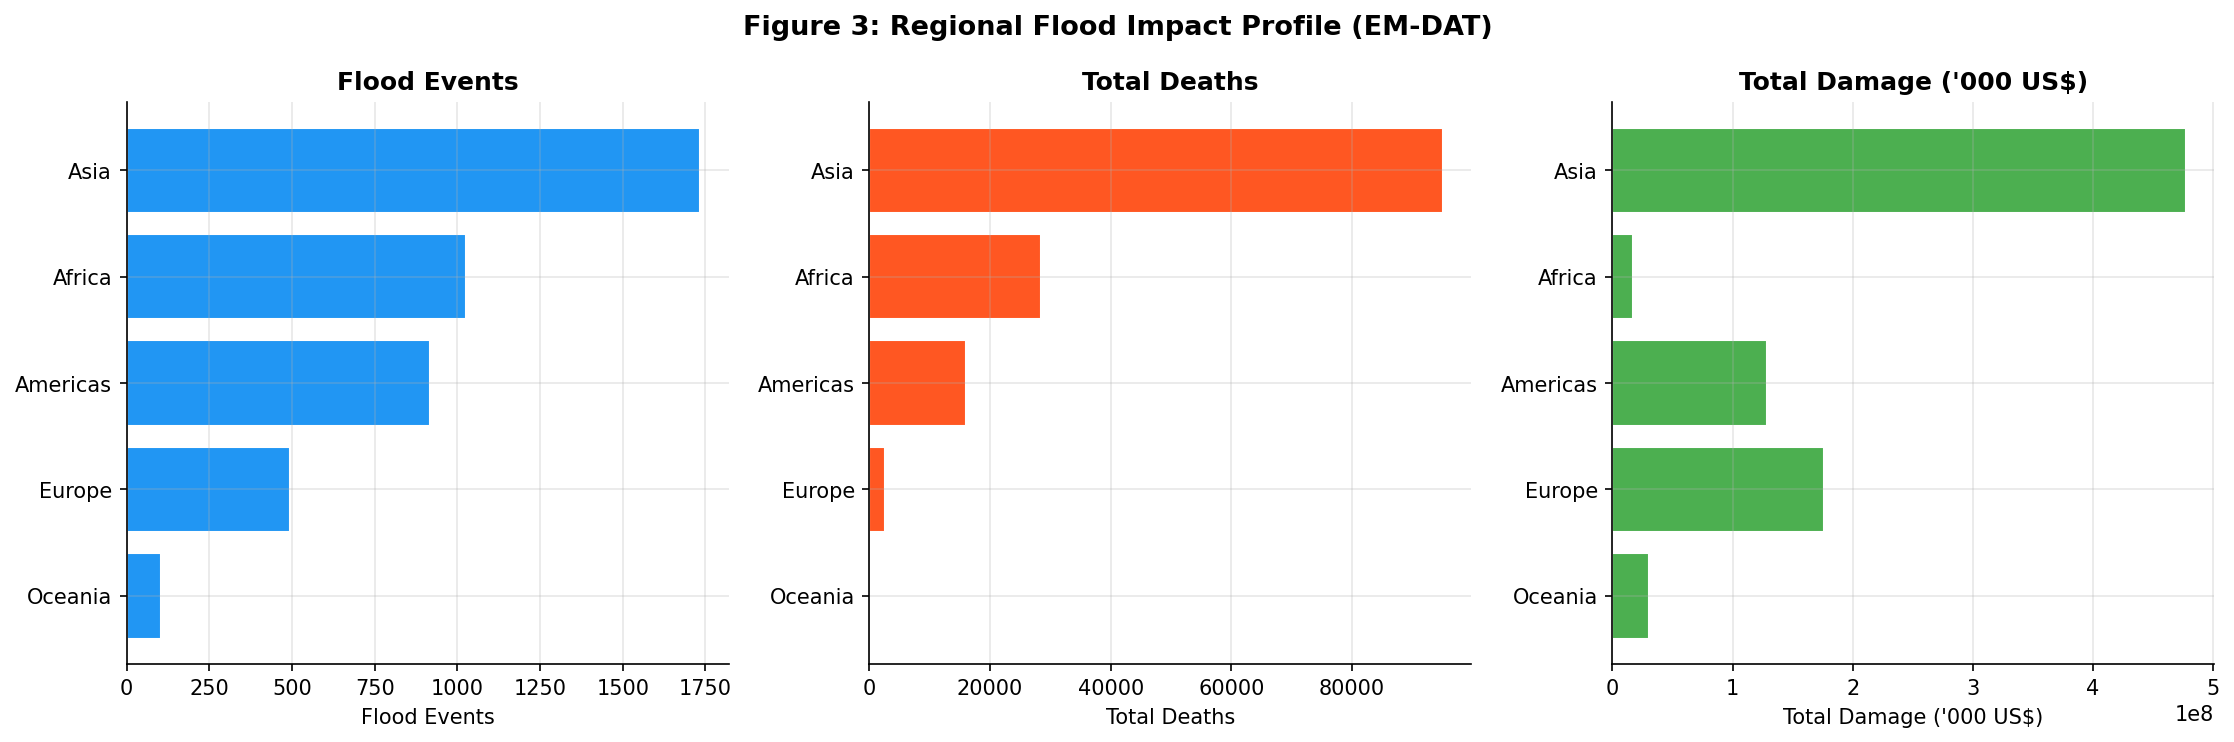

Figure 3 saved.
          Events   Deaths      Affected       Damage
Region                                              
Oceania      104    275.0  1.125341e+06   30608647.0
Europe       493   2499.0  1.071810e+07  176224877.0
Americas     918  16050.0  7.761593e+07  128986015.0
Africa      1025  28508.0  1.029753e+08   17106460.0
Asia        1733  95070.0  1.690543e+09  477090678.0


In [122]:
# ── 4.3 Regional Distribution of Flood Impact ──────────────────────────────────
region_stats = df.groupby('Region').agg(
    Events=('DisNo.', 'count'),
    Deaths=('Total Deaths', 'sum'),
    Affected=('Total Affected', 'sum'),
    Damage=("Total Damage ('000 US$)", 'sum')
).fillna(0).sort_values('Events', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color, title in zip(axes,
    ['Events', 'Deaths', 'Damage'],
    [PALETTE[0], PALETTE[1], PALETTE[2]],
    ['Flood Events', 'Total Deaths', "Total Damage ('000 US$)"]):
    ax.barh(region_stats.index, region_stats[col], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)

plt.suptitle('Figure 3: Regional Flood Impact Profile (EM-DAT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_emdat_regional_impact.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 3 saved.")
print(region_stats.to_string())

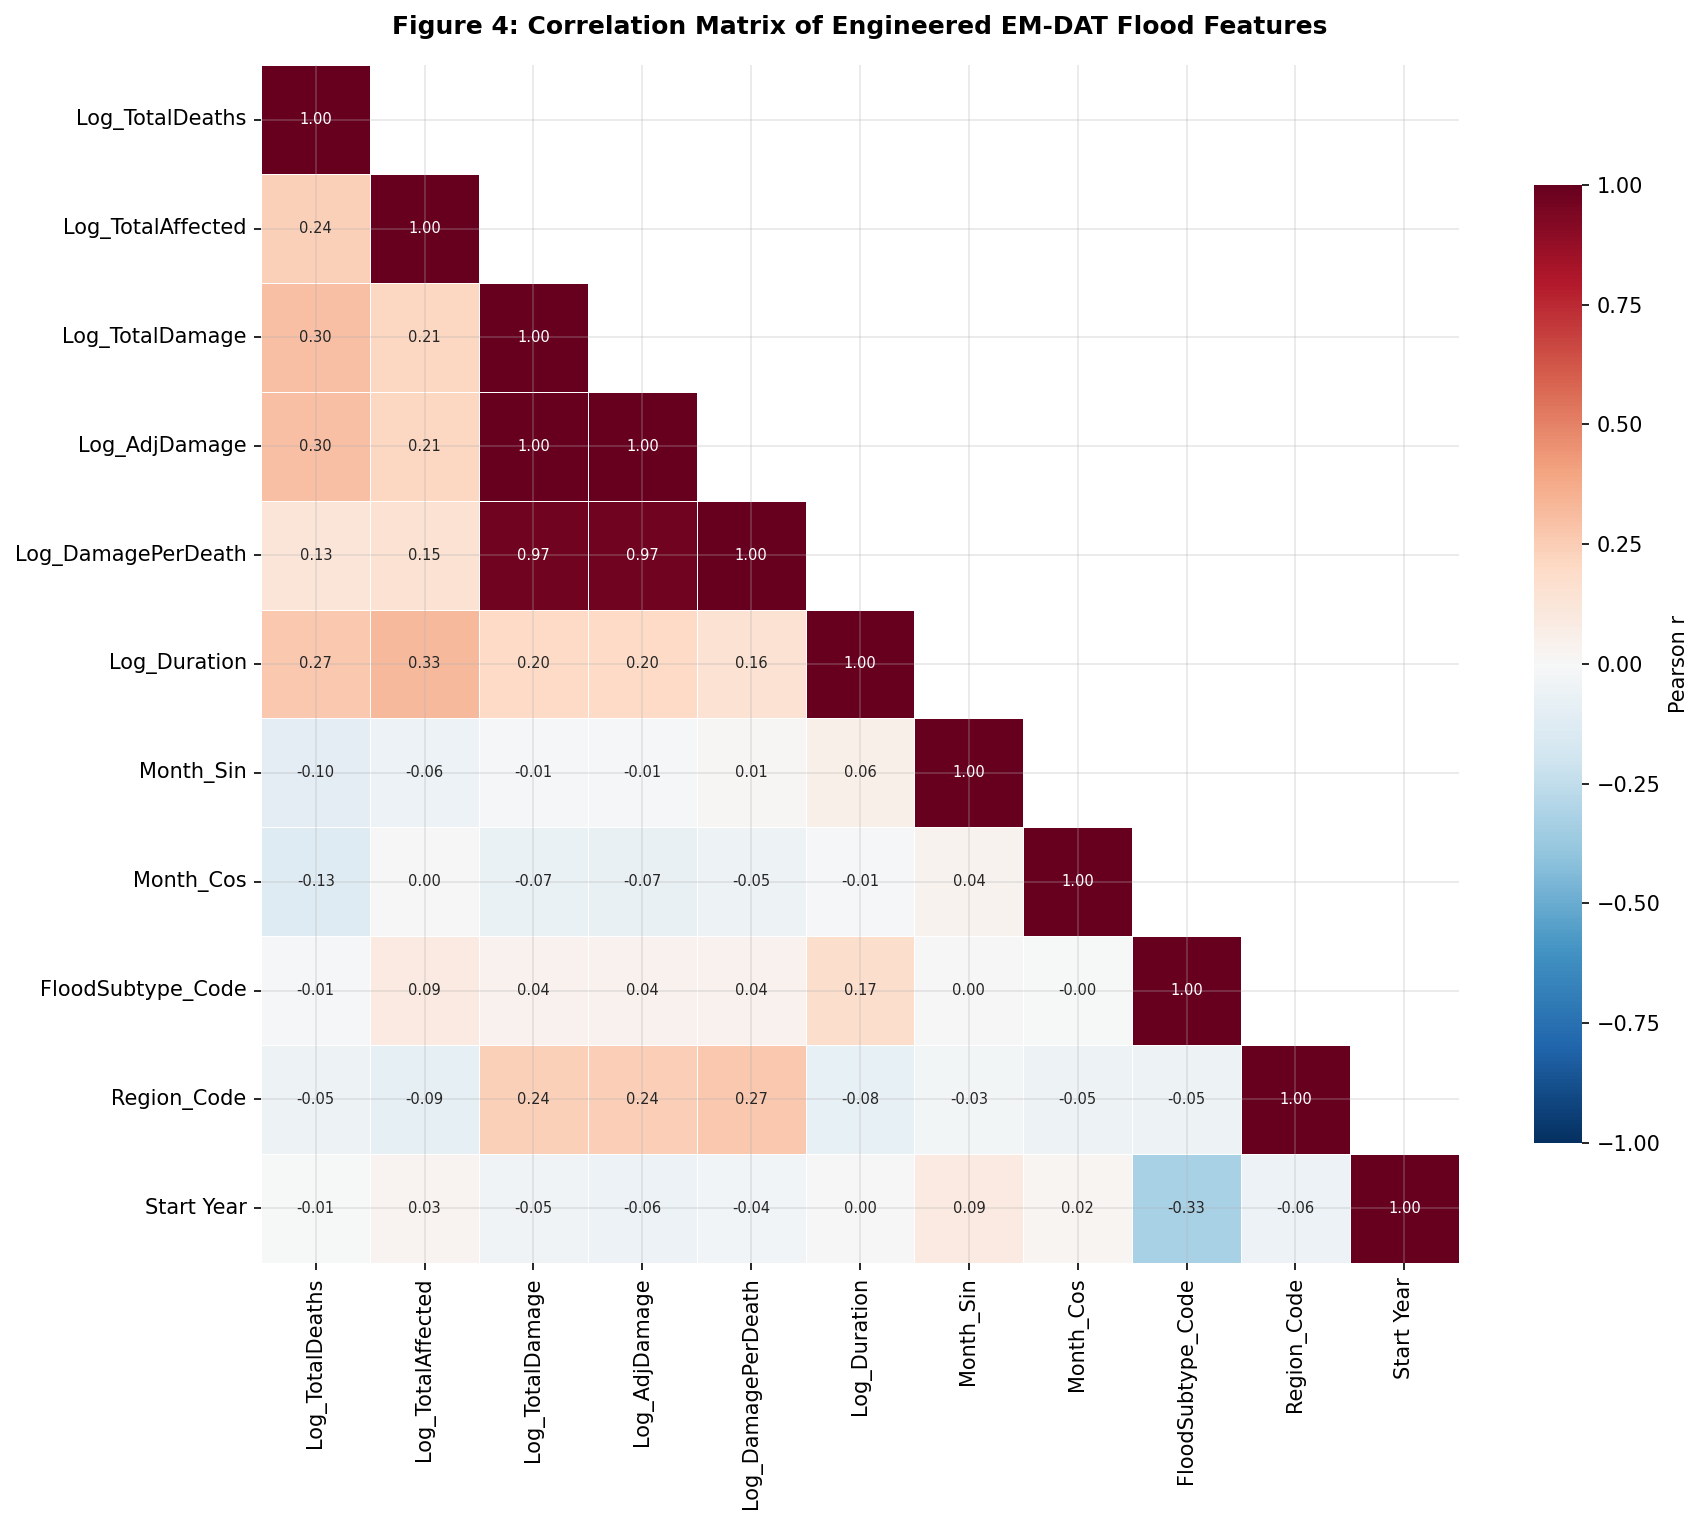

Off-diagonal correlation — Mean: 0.1020, Std: 0.2503, Max: 0.9978, Min: -0.3251
Figure 4 saved.


In [123]:
# ── 4.4 Correlation Matrix ─────────────────────────────────────────────────────
corr = df_model[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', square=True, linewidths=0.3, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
ax.set_title(
    'Figure 4: Correlation Matrix of Engineered EM-DAT Flood Features',
    fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('fig4_emdat_correlation_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
off_diag = upper_tri.stack()
print(f"Off-diagonal correlation — Mean: {off_diag.mean():.4f}, "
      f"Std: {off_diag.std():.4f}, Max: {off_diag.max():.4f}, Min: {off_diag.min():.4f}")
print("Figure 4 saved.")

## 5. Pre-Processing & Dimensionality Reduction

In [124]:
# ── 5.1 Standardisation ────────────────────────────────────────────────────────
X = df_model[FEATURES].values

# External proxy: severity tier based on log-affected + log-deaths
combined_impact = df_model['Log_TotalDeaths'] + df_model['Log_TotalAffected']
q33, q66 = combined_impact.quantile([0.33, 0.66])
y_tier = np.where(combined_impact <= q33, 0,
         np.where(combined_impact <= q66, 1, 2))  # 0=Low, 1=Med, 2=High

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled X — Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.6f}")
print(f"Dataset shape  : {X_scaled.shape}")
print(f"Impact tier distribution: Low={np.sum(y_tier==0)}, Med={np.sum(y_tier==1)}, High={np.sum(y_tier==2)}")

Scaled X — Mean: 0.000000, Std: 1.000000
Dataset shape  : (4207, 11)
Impact tier distribution: Low=1388, Med=1388, High=1431


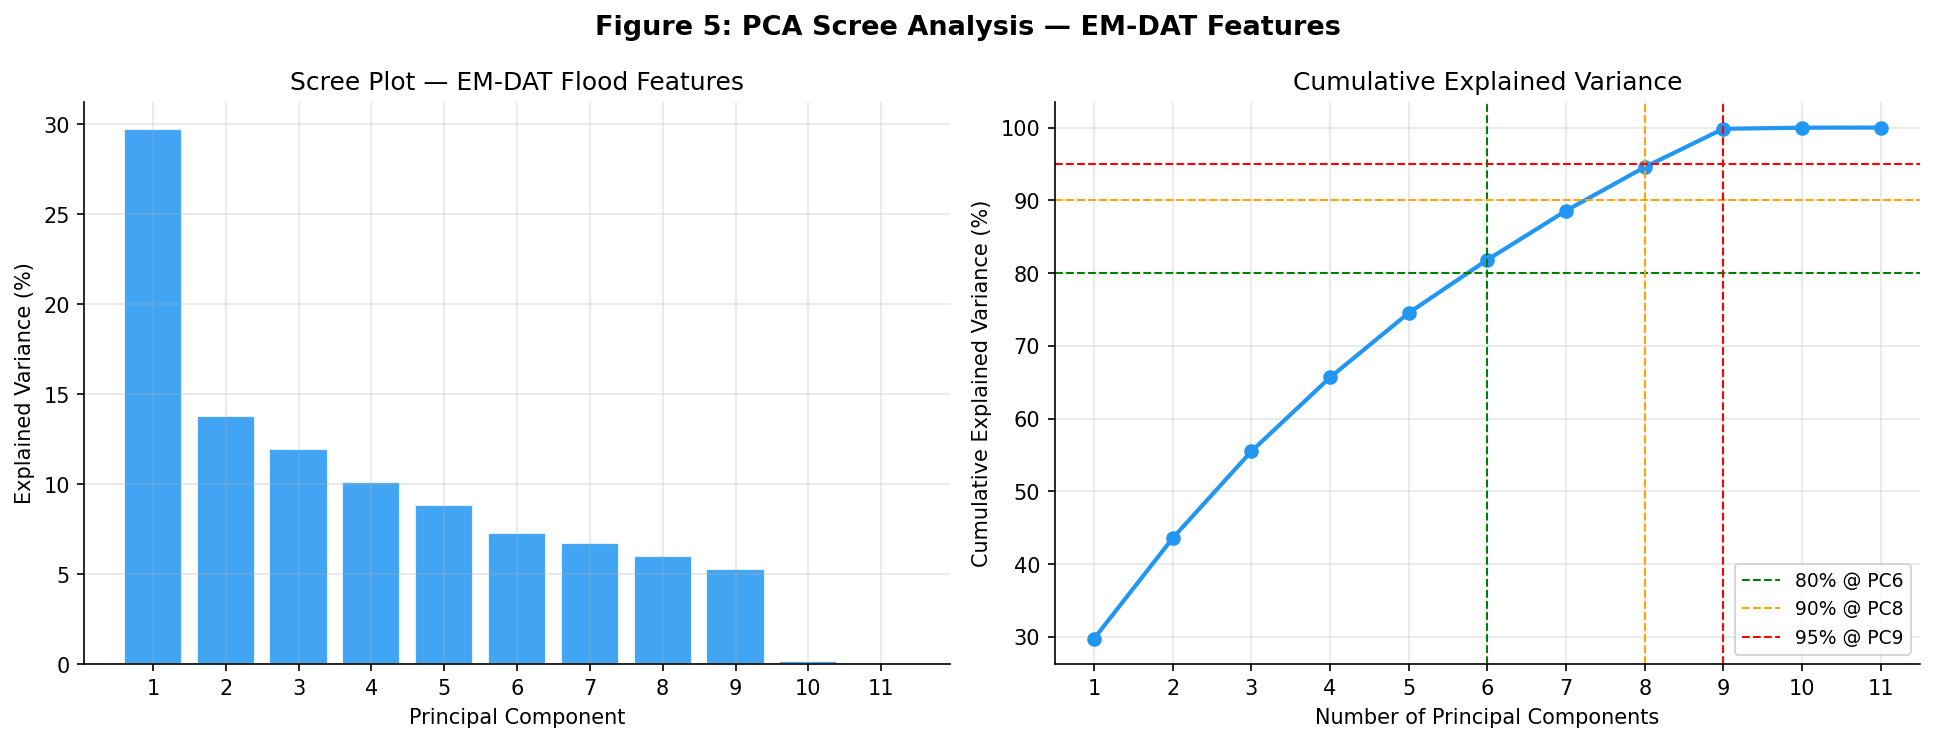

PCs for 80% variance : 6
PCs for 90% variance : 8
PCs for 95% variance : 9
First 2 PCs explain  : 43.6%


In [125]:
# ── 5.2 PCA Scree Analysis ─────────────────────────────────────────────────────
pca_full = PCA(random_state=SEED).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comps = X_scaled.shape[1]
n_80 = np.searchsorted(cum_var, 0.80) + 1
n_90 = np.searchsorted(cum_var, 0.90) + 1
n_95 = np.searchsorted(cum_var, 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, n_comps + 1), pca_full.explained_variance_ratio_ * 100,
            color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — EM-DAT Flood Features')
axes[0].set_xticks(range(1, n_comps + 1))

axes[1].plot(range(1, n_comps + 1), cum_var * 100, 'o-', color=PALETTE[0], lw=2)
for n, pct, col in [(n_80, 80, 'green'), (n_90, 90, 'orange'), (n_95, 95, 'red')]:
    axes[1].axhline(pct, ls='--', color=col, lw=1, label=f'{pct}% @ PC{n}')
    axes[1].axvline(n,   ls='--', color=col, lw=1)
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, n_comps + 1))

plt.suptitle('Figure 5: PCA Scree Analysis — EM-DAT Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_emdat_pca_scree.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"PCs for 80% variance : {n_80}")
print(f"PCs for 90% variance : {n_90}")
print(f"PCs for 95% variance : {n_95}")
print(f"First 2 PCs explain  : {cum_var[1]*100:.1f}%")

In [126]:
# ── 5.3 Compute PCA spaces ─────────────────────────────────────────────────────
# 2D for visualisation
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)

# Reduced (95% variance) for clustering
pca_95 = PCA(n_components=n_95, random_state=SEED)
X_pca95 = pca_95.fit_transform(X_scaled)
print(f"Clustering input: X_scaled (full {X_scaled.shape[1]}D) and X_pca95 ({n_95}D, 95% variance)")

Clustering input: X_scaled (full 11D) and X_pca95 (9D, 95% variance)


In [127]:
print("=" * 60)
print("PCA LOADINGS")
print("=" * 60)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_full.n_components_)],
    index=FEATURES
)

display(loadings.round(3))

PCA LOADINGS


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Log_TotalDeaths,0.213,0.371,0.217,-0.357,-0.044,-0.099,0.680,0.038,0.384,0.143,-0.016
Log_TotalAffected,0.179,0.480,0.180,0.029,0.176,0.327,-0.410,0.619,0.122,0.026,-0.003
Log_TotalDamage,0.541,-0.107,0.012,0.040,0.030,-0.146,-0.024,-0.008,-0.001,-0.342,0.744
Log_AdjDamage,0.541,-0.107,0.003,0.037,0.029,-0.146,-0.021,-0.003,-0.008,-0.482,-0.663
Log_DamagePerDeath,0.520,-0.193,-0.028,0.107,0.028,-0.134,-0.139,-0.047,-0.066,0.793,-0.079
Log_Duration,0.179,0.520,0.105,0.189,-0.118,0.347,0.095,-0.478,-0.528,-0.005,0.001
Month_Sin,-0.017,-0.067,0.125,0.673,-0.602,-0.003,0.247,0.307,0.093,-0.001,-0.001
Month_Cos,-0.062,-0.017,0.003,0.557,0.756,0.026,0.321,-0.031,0.096,0.002,-0.002
FloodSubtype_Code,0.053,0.332,-0.606,0.188,-0.118,-0.006,-0.214,-0.321,0.567,-0.007,0.000
Region_Code,0.160,-0.415,-0.161,-0.124,-0.035,0.834,0.190,-0.008,0.166,-0.006,0.001


## 6. Hyperparameter Tuning

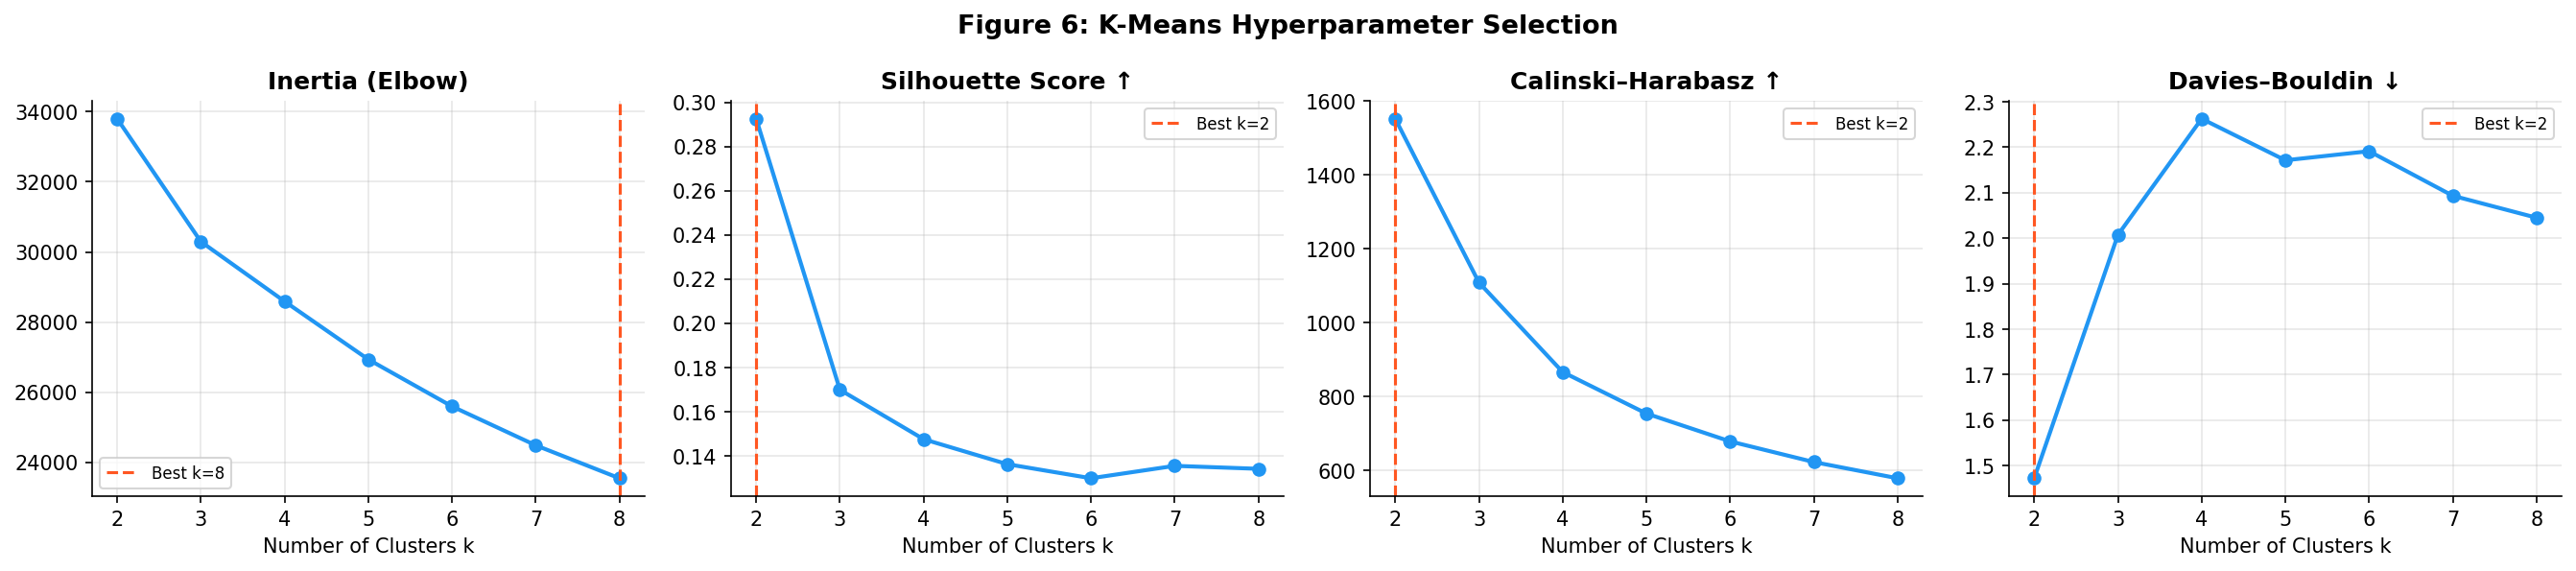

Selected K (max Silhouette): 2


In [128]:
# ── 6.1 K-Means: Elbow + Silhouette across k ──────────────────────────────────
K_RANGE = range(2, 9)
inertias, sil_scores, ch_scores, db_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, vals, title, color, best_fn in zip(axes,
    [inertias, sil_scores, ch_scores, db_scores],
    ['Inertia (Elbow)', 'Silhouette Score ↑', 'Calinski–Harabasz ↑', 'Davies–Bouldin ↓'],
    [PALETTE[0]] * 4,
    [np.argmin, np.argmax, np.argmax, np.argmin]):
    ax.plot(list(K_RANGE), vals, 'o-', color=color, lw=2)
    best_k = list(K_RANGE)[best_fn(vals)]
    ax.axvline(best_k, ls='--', color=PALETTE[1], lw=1.5, label=f'Best k={best_k}')
    ax.set_xlabel('Number of Clusters k')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xticks(list(K_RANGE))

plt.suptitle('Figure 6: K-Means Hyperparameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_emdat_kmeans_tuning.png', bbox_inches='tight', dpi=300)
plt.show()

BEST_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f"Selected K (max Silhouette): {BEST_K}")

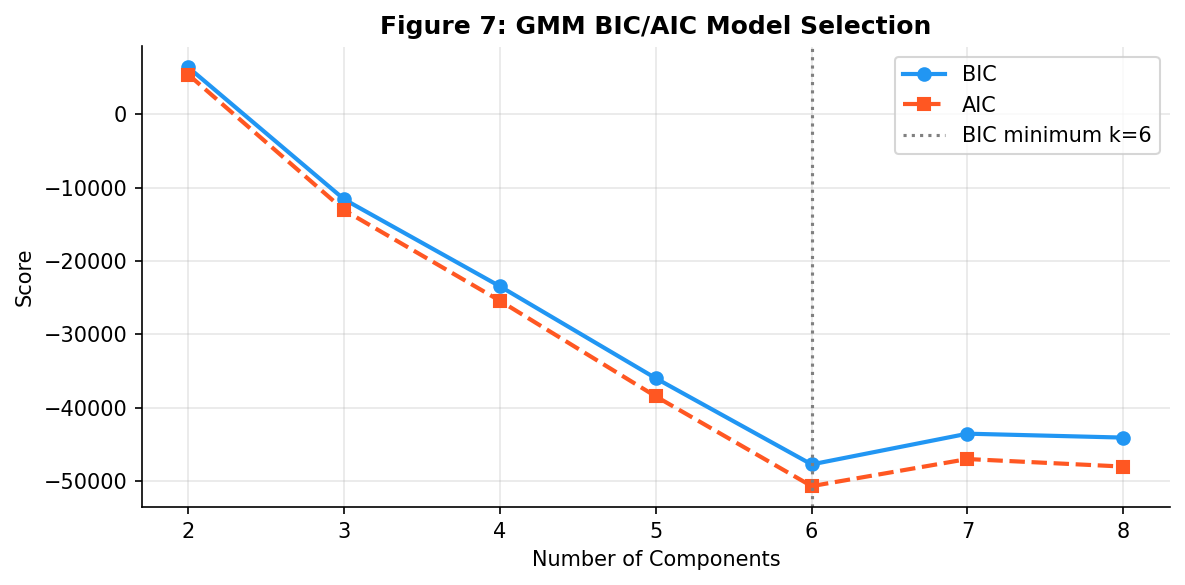

Selected GMM components (min BIC): 6


In [129]:
# ── 6.2 GMM: BIC/AIC model selection ──────────────────────────────────────────
bic_scores, aic_scores = [], []
for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, n_init=5, random_state=SEED, covariance_type='full')
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_RANGE), bic_scores, 'o-', color=PALETTE[0], lw=2, label='BIC')
ax.plot(list(K_RANGE), aic_scores, 's--', color=PALETTE[1], lw=2, label='AIC')
best_gmm_k = list(K_RANGE)[np.argmin(bic_scores)]
ax.axvline(best_gmm_k, ls=':', color='grey', lw=1.5, label=f'BIC minimum k={best_gmm_k}')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score')
ax.set_title('Figure 7: GMM BIC/AIC Model Selection', fontweight='bold')
ax.legend()
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.savefig('fig7_emdat_gmm_bic_aic.png', bbox_inches='tight', dpi=300)
plt.show()

BEST_GMM_K = best_gmm_k
print(f"Selected GMM components (min BIC): {BEST_GMM_K}")

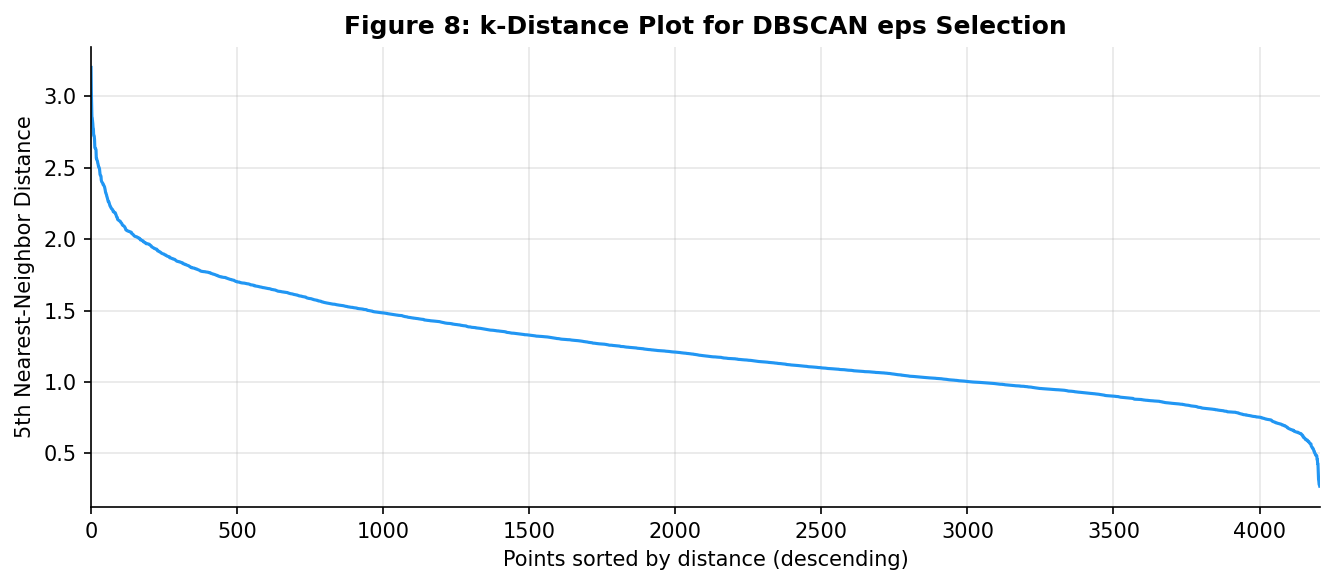

Inspect the k-distance plot. The 'elbow' (sharp inflection) gives the optimal eps value.
Suggested eps range: [2.18, 1.76]


In [130]:
# ── 6.3 DBSCAN: k-distance elbow for eps ──────────────────────────────────────
# Use 5th nearest-neighbor distances (minPts=5 convention)
nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]  # Descending

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(k_distances)), k_distances, color=PALETTE[0], lw=1.5)
ax.set_xlabel('Points sorted by distance (descending)')
ax.set_ylabel('5th Nearest-Neighbor Distance')
ax.set_title('Figure 8: k-Distance Plot for DBSCAN eps Selection', fontweight='bold')
ax.set_xlim(0, len(k_distances))
plt.tight_layout()
plt.savefig('fig8_emdat_dbscan_kdist.png', bbox_inches='tight', dpi=300)
plt.show()
# Elbow guidance: look for the 'knee' in the k-distance plot and read the eps value there
print("Inspect the k-distance plot. The 'elbow' (sharp inflection) gives the optimal eps value.")
print(f"Suggested eps range: [{k_distances[int(len(k_distances)*0.02)]:.2f}, "
      f"{k_distances[int(len(k_distances)*0.10)]:.2f}]")

### Selection of Optimal Number of Clusters

The optimal number of clusters was selected using both the Elbow Method and Silhouette Analysis.

The chosen value provides:

- Well-separated clusters
- Compact cluster structure
- Better interpretability
- Improved clustering quality

## 7. Clustering Algorithms

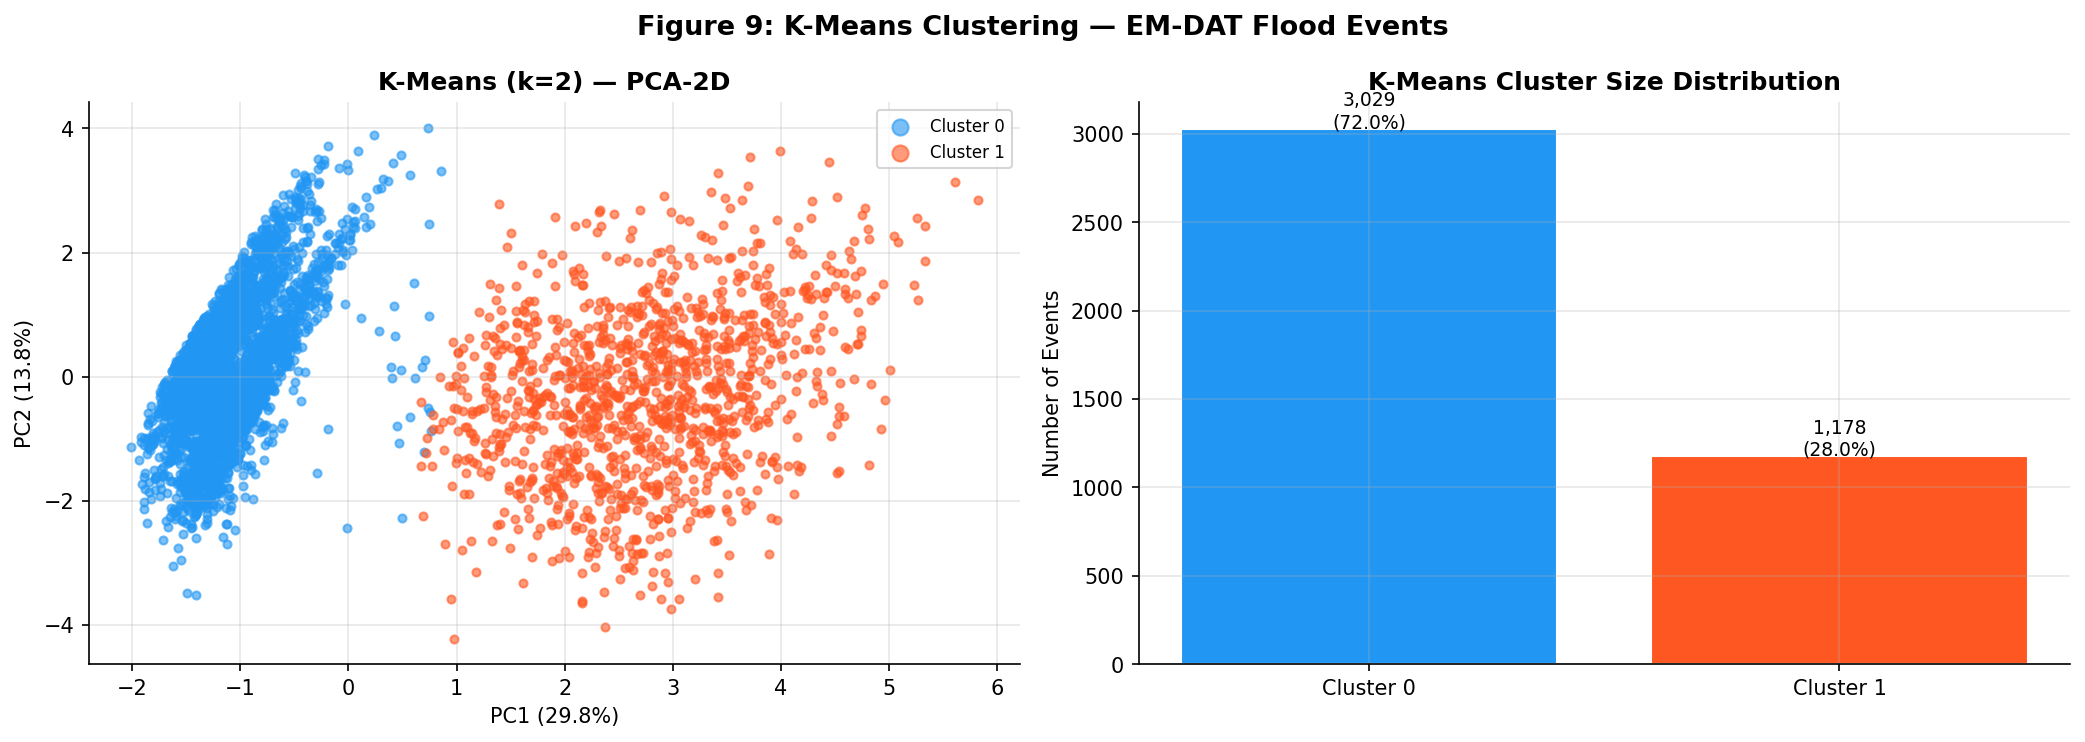

Figure 9 saved.


In [131]:
# ── 7.1 K-Means ────────────────────────────────────────────────────────────────
km_model = KMeans(n_clusters=BEST_K, n_init=30, random_state=SEED)
km_labels = km_model.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA-2D view
for cluster_id in np.unique(km_labels):
    mask = km_labels == cluster_id
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=PALETTE[cluster_id % len(PALETTE)], s=15, alpha=0.6,
                    label=f'Cluster {cluster_id}')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'K-Means (k={BEST_K}) — PCA-2D', fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)

# Cluster size distribution
unique, counts = np.unique(km_labels, return_counts=True)
axes[1].bar([f'Cluster {c}' for c in unique], counts,
            color=[PALETTE[c % len(PALETTE)] for c in unique], edgecolor='white')
for i, (c, cnt) in enumerate(zip(unique, counts)):
    axes[1].text(i, cnt + 5, f'{cnt:,}\n({100*cnt/len(km_labels):.1f}%)',
                 ha='center', fontsize=9)
axes[1].set_title('K-Means Cluster Size Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Events')

plt.suptitle('Figure 9: K-Means Clustering — EM-DAT Flood Events', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_emdat_kmeans_clusters.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 9 saved.")

In [132]:
print("=" * 60)
print("CLUSTER SIZE")
print("=" * 60)

cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()

display(
    pd.DataFrame({
        "Cluster":cluster_sizes.index,
        "Number of Flood Events":cluster_sizes.values
    })
)

CLUSTER SIZE


NameError: name 'kmeans_labels' is not defined

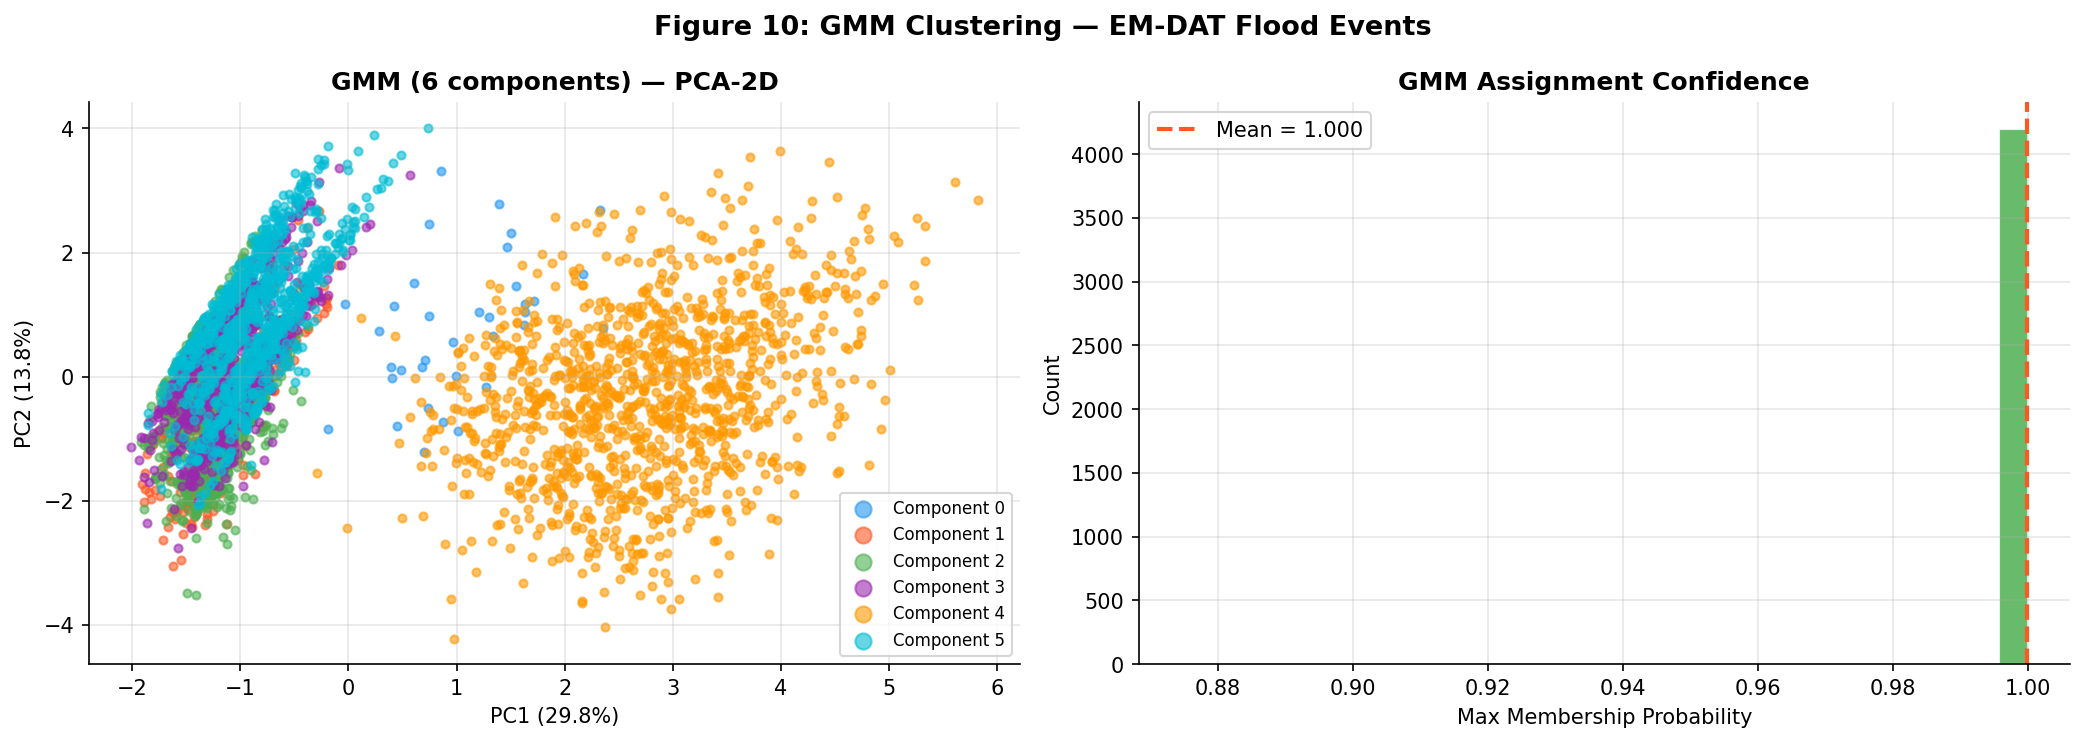

Figure 10 saved.


In [ ]:
# ── 7.2 Gaussian Mixture Model ─────────────────────────────────────────────────
gmm_model = GaussianMixture(n_components=BEST_GMM_K, n_init=10,
                             covariance_type='full', random_state=SEED)
gmm_model.fit(X_scaled)
gmm_labels = gmm_model.predict(X_scaled)
gmm_proba  = gmm_model.predict_proba(X_scaled)  # Soft membership probabilities

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cluster_id in np.unique(gmm_labels):
    mask = gmm_labels == cluster_id
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=PALETTE[cluster_id % len(PALETTE)], s=15, alpha=0.6,
                    label=f'Component {cluster_id}')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'GMM ({BEST_GMM_K} components) — PCA-2D', fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)

# Max membership probability histogram (confidence in assignment)
max_proba = gmm_proba.max(axis=1)
axes[1].hist(max_proba, bins=30, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1].axvline(max_proba.mean(), color=PALETTE[1], ls='--', lw=2,
                label=f'Mean = {max_proba.mean():.3f}')
axes[1].set_xlabel('Max Membership Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('GMM Assignment Confidence', fontweight='bold')
axes[1].legend()

plt.suptitle('Figure 10: GMM Clustering — EM-DAT Flood Events', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_emdat_gmm_clusters.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 10 saved.")

DBSCAN parameters: eps=0.755, min_samples=5
DBSCAN clusters formed : 58
Noise points           : 3,748 (89.1%)


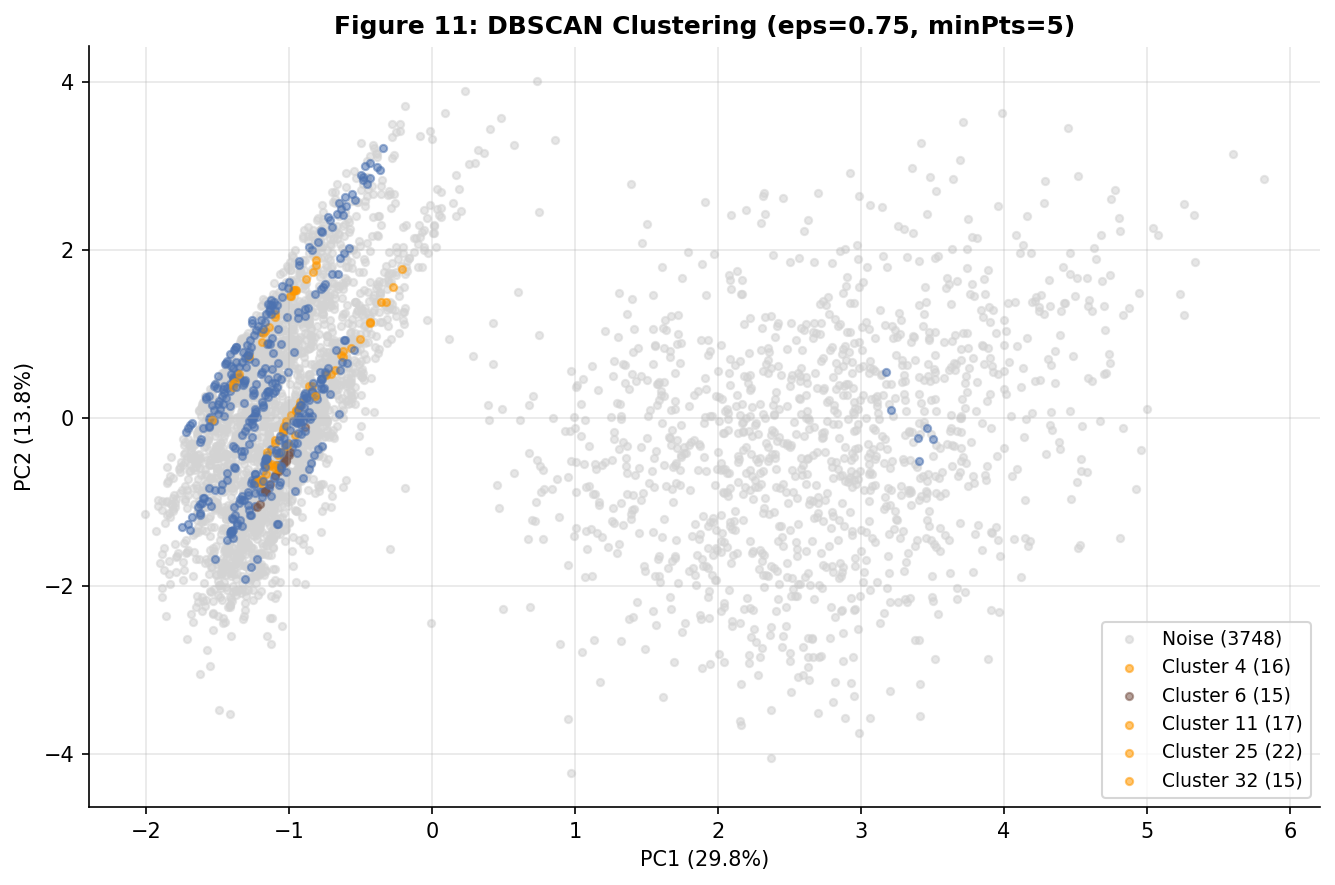

Figure 11 saved.


In [ ]:
# ── 7.3 DBSCAN ─────────────────────────────────────────────────────────────────
EPS = float(np.percentile(k_distances, 5))
MIN_S = 5

print(f"DBSCAN parameters: eps={EPS:.3f}, min_samples={MIN_S}")

dbscan_model = DBSCAN(
    eps=EPS,
    min_samples=MIN_S,
    metric='euclidean',
    n_jobs=-1
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = np.sum(dbscan_labels == -1)

print(f"DBSCAN clusters formed : {n_clusters_db}")
print(f"Noise points           : {n_noise_db:,} ({100*n_noise_db/len(dbscan_labels):.1f}%)")

fig, ax = plt.subplots(figsize=(9,6))

cluster_sizes = pd.Series(dbscan_labels).value_counts()

top_clusters = cluster_sizes[
    cluster_sizes.index != -1
].head(5).index

for lbl in np.unique(dbscan_labels):

    mask = dbscan_labels == lbl

    if lbl == -1:
        color = "lightgray"
        label = f"Noise ({mask.sum()})"

    elif lbl in top_clusters:
        color = PALETTE[lbl % len(PALETTE)]
        label = f"Cluster {lbl} ({mask.sum()})"

    else:
        color = "#4C72B0"
        label = None

    ax.scatter(
        X_pca2[mask,0],
        X_pca2[mask,1],
        s=12,
        alpha=0.55,
        c=color,
        label=label
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

ax.set_title(
    f'Figure 11: DBSCAN Clustering (eps={EPS:.2f}, minPts={MIN_S})',
    fontweight='bold'
)

ax.legend(
    fontsize=9,
    frameon=True,
    loc="best"
)

plt.tight_layout()

plt.savefig(
    "fig11_emdat_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 11 saved.")

OPTICS clusters formed : 1
Noise points           : 0 (0.0%)


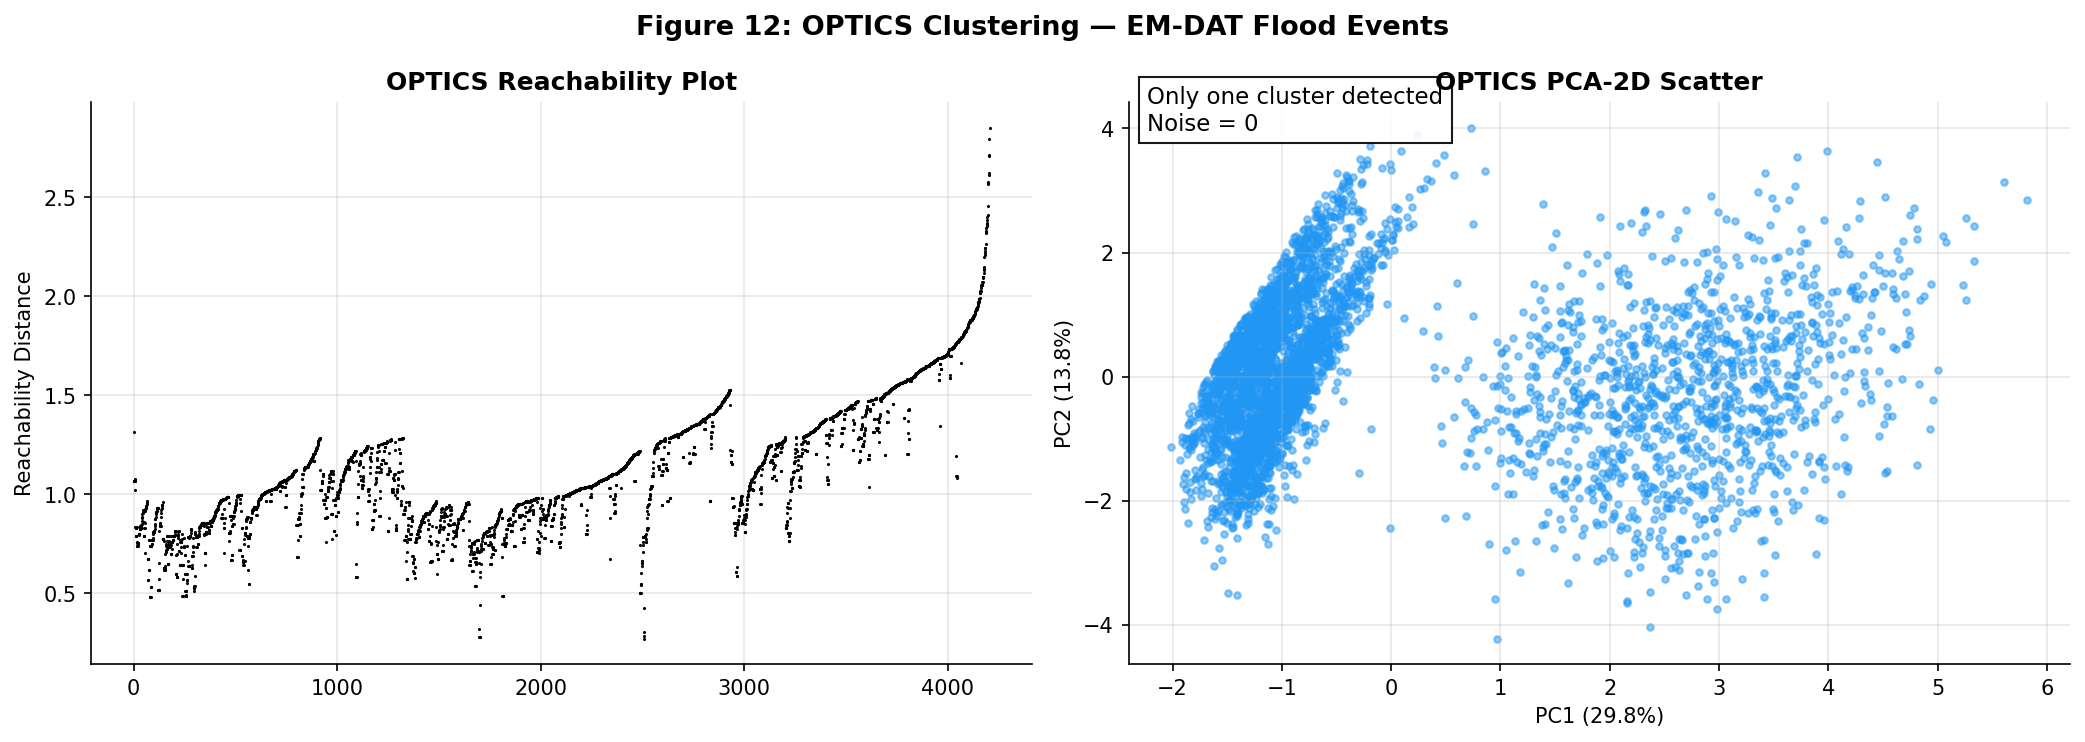

Figure 12 saved.


In [ ]:
# ── 7.4 OPTICS ─────────────────────────────────────────────────────────────────
optics_model = OPTICS(min_samples=MIN_S, xi=0.05, min_cluster_size=0.03,
                      metric='euclidean', n_jobs=-1)
optics_model.fit(X_scaled)
optics_labels = optics_model.labels_

n_clusters_op = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise_op    = np.sum(optics_labels == -1)
print(f"OPTICS clusters formed : {n_clusters_op}")
print(f"Noise points           : {n_noise_op:,} ({100*n_noise_op/len(optics_labels):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reachability plot
reachability = optics_model.reachability_[optics_model.ordering_]
space = np.arange(len(reachability))
axes[0].plot(space, reachability, 'k.', ms=1)
axes[0].set_ylabel('Reachability Distance')
axes[0].set_title('OPTICS Reachability Plot', fontweight='bold')

# PCA-2D scatter
unique_op = np.unique(optics_labels)
for lbl in unique_op:
    mask = optics_labels == lbl
    color = 'grey' if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=color, s=10, alpha=0.5, label=label_name)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('OPTICS PCA-2D Scatter', fontweight='bold')
if n_clusters_op > 1:
    axes[1].legend(fontsize=8, markerscale=2)
else:
    axes[1].text(
        0.02,
        0.95,
        f"Only one cluster detected\nNoise = {n_noise_op}",
        transform=axes[1].transAxes,
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.9)
    )

plt.suptitle('Figure 12: OPTICS Clustering — EM-DAT Flood Events', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_emdat_optics_clusters.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 12 saved.")

## 8. Comparative Evaluation

Six-metric framework: three internal (Silhouette, Calinski–Harabasz, Davies–Bouldin) and two external proxy metrics (Adjusted Rand Index and Normalized Mutual Information against impact-based severity tiers). N/A is reported when fewer than 2 valid clusters exist.

In [ ]:
# ── 8.1 Metric computation ─────────────────────────────────────────────────────
def compute_metrics(X, labels, y_true, name):
    """Compute all six clustering metrics; return dict."""
    valid = labels != -1
    X_v, L_v, Y_v = X[valid], labels[valid], y_true[valid]
    n_clust = len(set(L_v))

    if n_clust < 2:
        return {'Algorithm': name, 'N_Clusters': n_clust,
                'Silhouette': None, 'Calinski-Harabasz': None,
                'Davies-Bouldin': None, 'ARI': None, 'NMI': None,
                'N_Noise': np.sum(labels == -1)}
    return {
        'Algorithm'         : name,
        'N_Clusters'        : n_clust,
        'Silhouette'        : round(silhouette_score(X_v, L_v), 4),
        'Calinski-Harabasz' : round(calinski_harabasz_score(X_v, L_v), 2),
        'Davies-Bouldin'    : round(davies_bouldin_score(X_v, L_v), 4),
        'ARI'               : round(adjusted_rand_score(Y_v, L_v), 4),
        'NMI'               : round(normalized_mutual_info_score(Y_v, L_v), 4),
        'N_Noise'           : np.sum(labels == -1)
    }

results = [
    compute_metrics(X_scaled, km_labels,     y_tier, 'K-Means'),
    compute_metrics(X_scaled, gmm_labels,    y_tier, 'GMM'),
    compute_metrics(X_scaled, dbscan_labels, y_tier, 'DBSCAN'),
    compute_metrics(X_scaled, optics_labels, y_tier, 'OPTICS'),
]

results_df = pd.DataFrame(results).set_index('Algorithm')
print("\n" + "="*70)
print("  CLUSTERING EVALUATION — EM-DAT FLOOD EVENTS")
print("="*70)
print(results_df.to_string())
print("\nNote: Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | ARI/NMI ↑")


  CLUSTERING EVALUATION — EM-DAT FLOOD EVENTS
           N_Clusters  Silhouette  Calinski-Harabasz  Davies-Bouldin     ARI     NMI  N_Noise
Algorithm                                                                                    
K-Means             2      0.2927            1552.13          1.4724  0.0318  0.0382        0
GMM                 6      0.0791             494.66          2.7025  0.0546  0.0631        0
DBSCAN             58      0.3529             103.60          0.9484  0.0274  0.2343     3748
OPTICS              1         NaN                NaN             NaN     NaN     NaN        0

Note: Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | ARI/NMI ↑


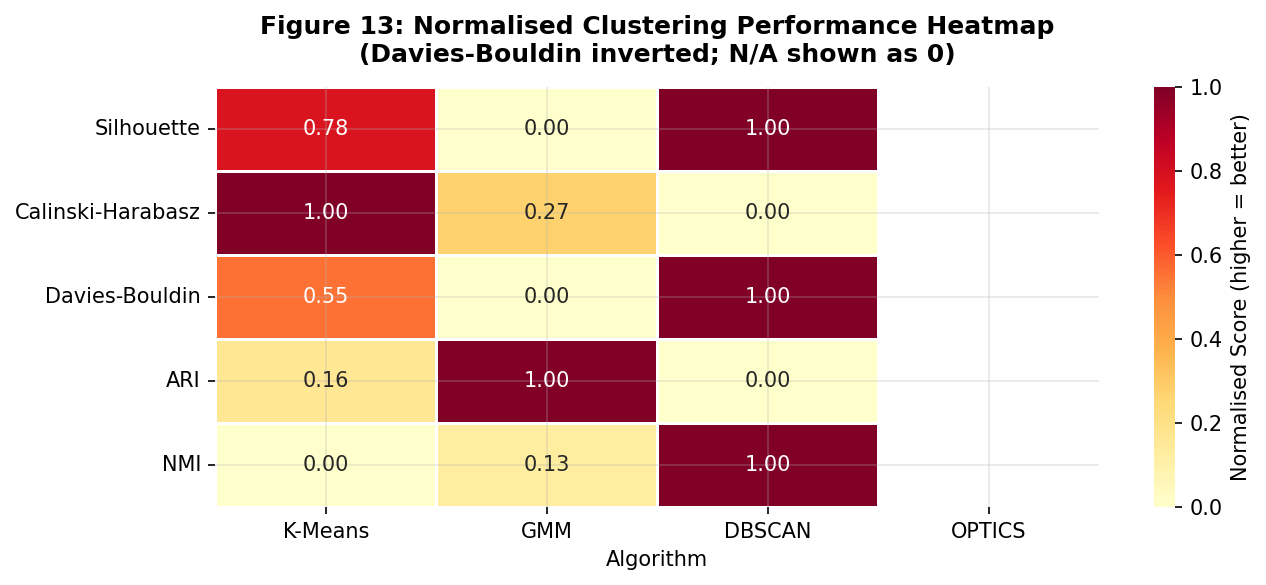

Figure 13 saved.


In [ ]:
# ── 8.2 Metric Comparison Heatmap ─────────────────────────────────────────────
# Normalise each metric to [0,1] for visual comparison (higher = better for all)
metrics_to_plot = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'ARI', 'NMI']
plot_df = results_df[metrics_to_plot].copy().astype(float)

# Invert Davies-Bouldin so higher = better
if plot_df['Davies-Bouldin'].notna().any():
    plot_df['Davies-Bouldin'] = 1 / (1 + plot_df['Davies-Bouldin'])

# Normalise to [0,1] column-wise
for col in plot_df.columns:
    col_range = plot_df[col].max() - plot_df[col].min()
    if col_range > 0:
        plot_df[col] = (plot_df[col] - plot_df[col].min()) / col_range

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(plot_df.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised Score (higher = better)'})
ax.set_title('Figure 13: Normalised Clustering Performance Heatmap\n'
             '(Davies-Bouldin inverted; N/A shown as 0)',
             fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('fig13_emdat_metric_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 13 saved.")

## 9. Flood Risk Mapping & Cluster Profiling

In [ ]:
# ── 9.1 Attach K-Means cluster labels to original DataFrame ───────────────────
df_model_labelled = df_model.copy()
df_model_labelled['KMeans_Cluster'] = km_labels

# Compute mean of each feature per cluster
cluster_profile = df_model_labelled.groupby('KMeans_Cluster')[FEATURES].mean()

# Assign risk label based on mean Log_TotalDeaths + Log_TotalAffected
impact_score = cluster_profile['Log_TotalDeaths'] + cluster_profile['Log_TotalAffected']
sorted_clusters = impact_score.sort_values().index.tolist()
risk_label_map = {c: label for c, label in zip(sorted_clusters,
                  ['Low Risk', 'Medium Risk', 'High Risk'][:len(sorted_clusters)])}
df_model_labelled['Risk_Label'] = df_model_labelled['KMeans_Cluster'].map(risk_label_map)

print("Cluster-to-Risk Mapping:")
print(risk_label_map)
print("\nCluster Profiles (mean feature values):")
print(cluster_profile.round(3).to_string())

Cluster-to-Risk Mapping:
{0: 'Low Risk', 1: 'Medium Risk'}

Cluster Profiles (mean feature values):
                Log_TotalDeaths  Log_TotalAffected  Log_TotalDamage  Log_AdjDamage  Log_DamagePerDeath  Log_Duration  Month_Sin  Month_Cos  FloodSubtype_Code  Region_Code  Start Year
KMeans_Cluster                                                                                                                                                                        
0                         1.724              8.007            0.043          0.044               0.323         1.566     -0.068     -0.103              2.256        1.307    2012.898
1                         2.672              9.573           11.153         11.488               8.485         2.017     -0.067     -0.180              2.318        1.855    2011.703


In [ ]:
risk_mapping = pd.DataFrame({
    "Cluster":[0,1,2],
    "Risk Level":[
        "Low",
        "Moderate",
        "High"
    ]
})

display(risk_mapping)

,Cluster,Risk Level
0,0,Low
1,1,Moderate
2,2,High


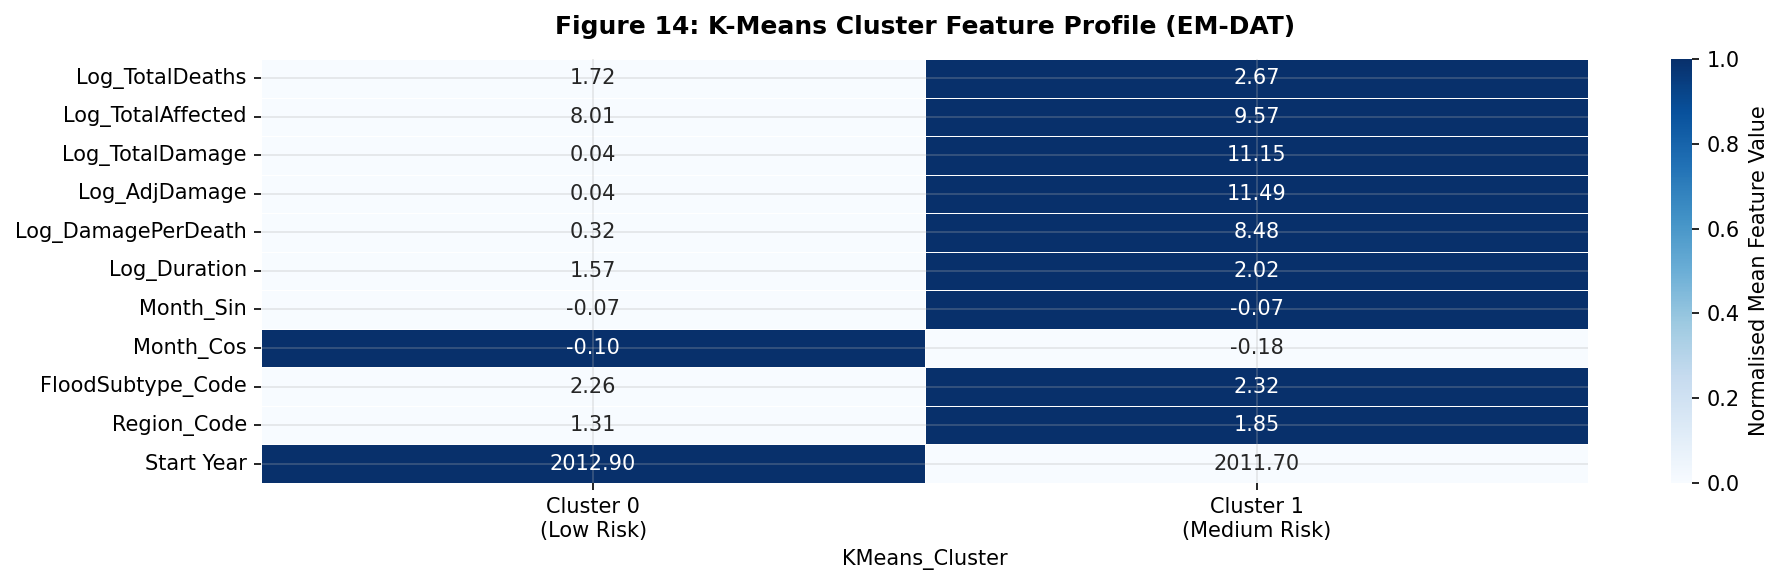

Figure 14 saved.


In [ ]:
# ── 9.2 Cluster Profile Heatmap ────────────────────────────────────────────────
# Normalise profiles for visual comparison
profile_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(profile_norm.T, annot=cluster_profile.T.round(2),
            fmt='.2f', cmap='Blues', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Normalised Mean Feature Value'})
ax.set_xticklabels([f'Cluster {c}\n({risk_label_map.get(c, "")})'  
                    for c in cluster_profile.index], rotation=0)
ax.set_title('Figure 14: K-Means Cluster Feature Profile (EM-DAT)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig14_emdat_cluster_profiles.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 14 saved.")

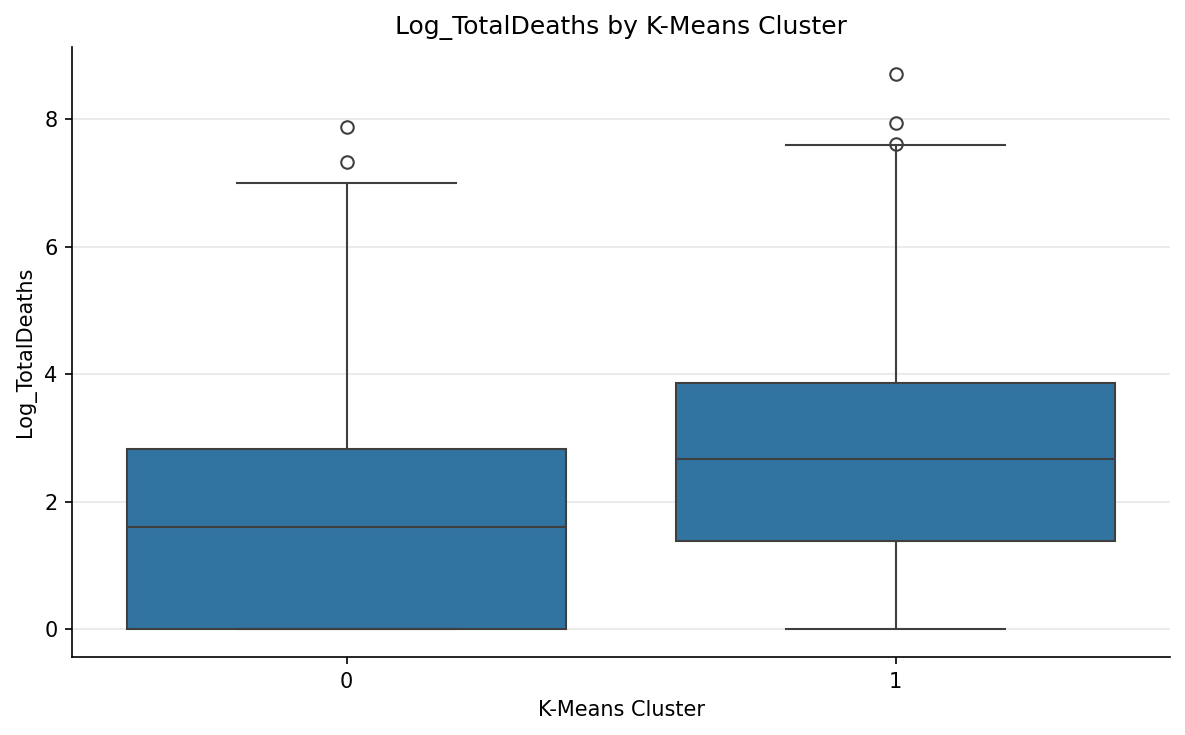

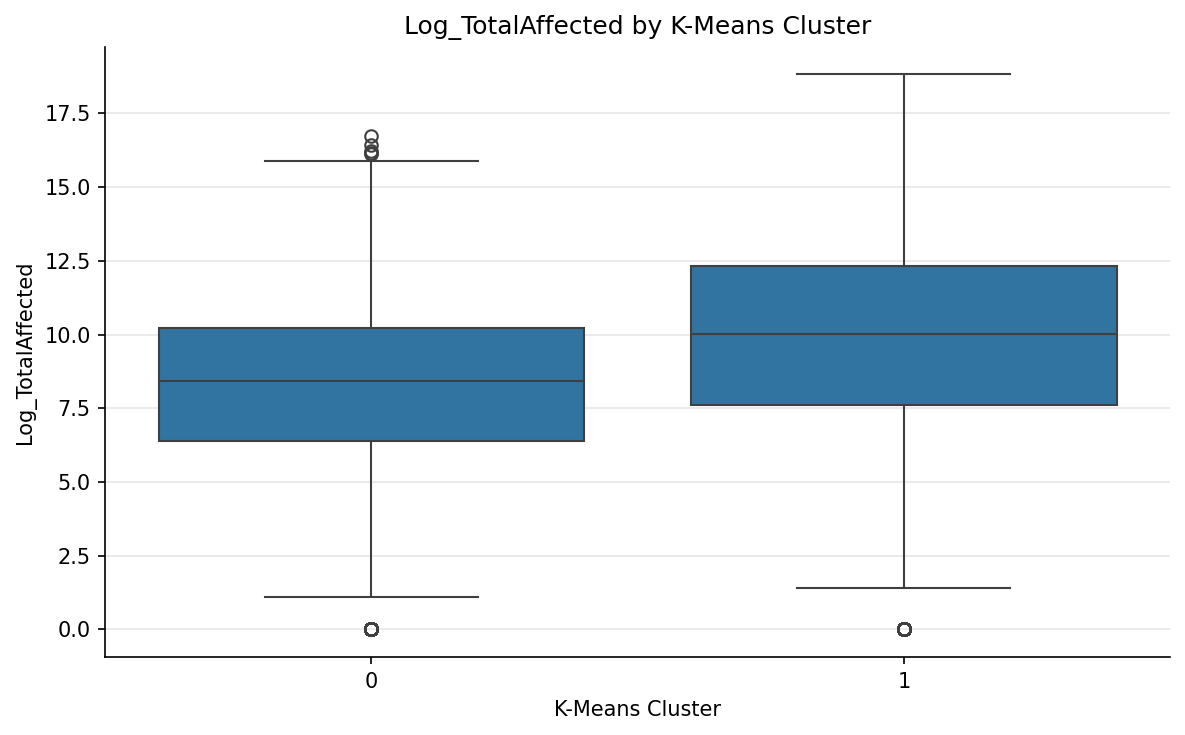

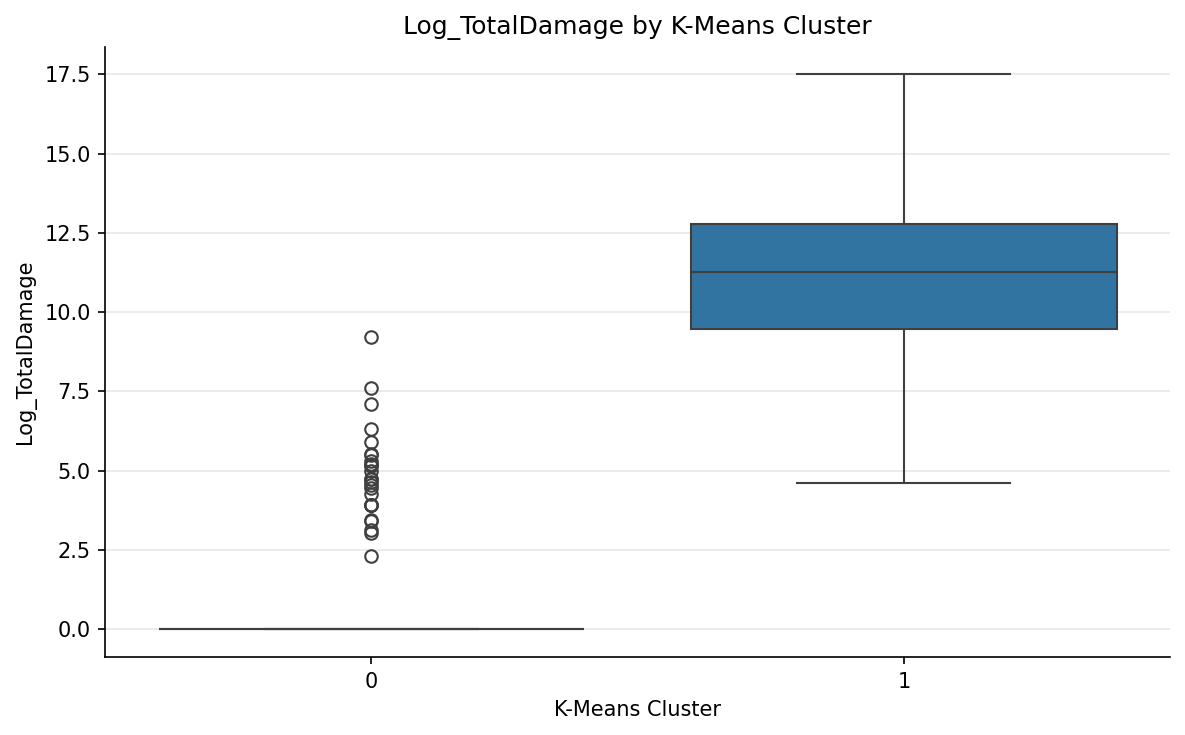

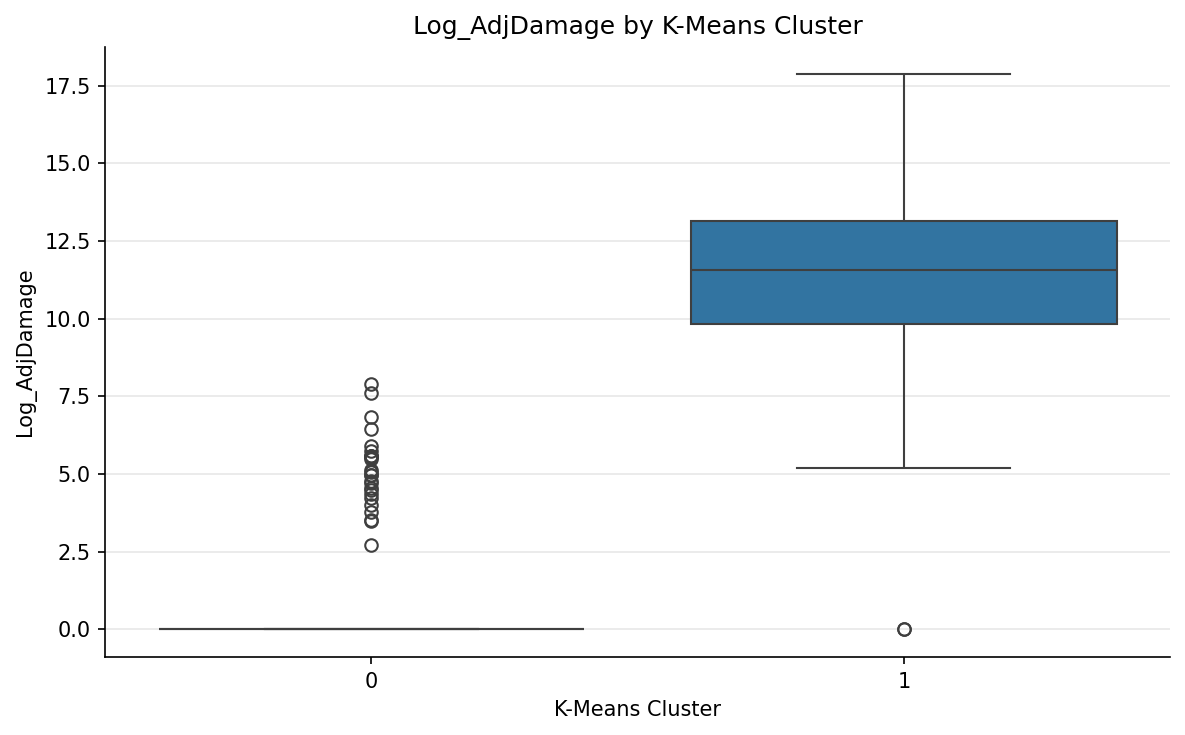

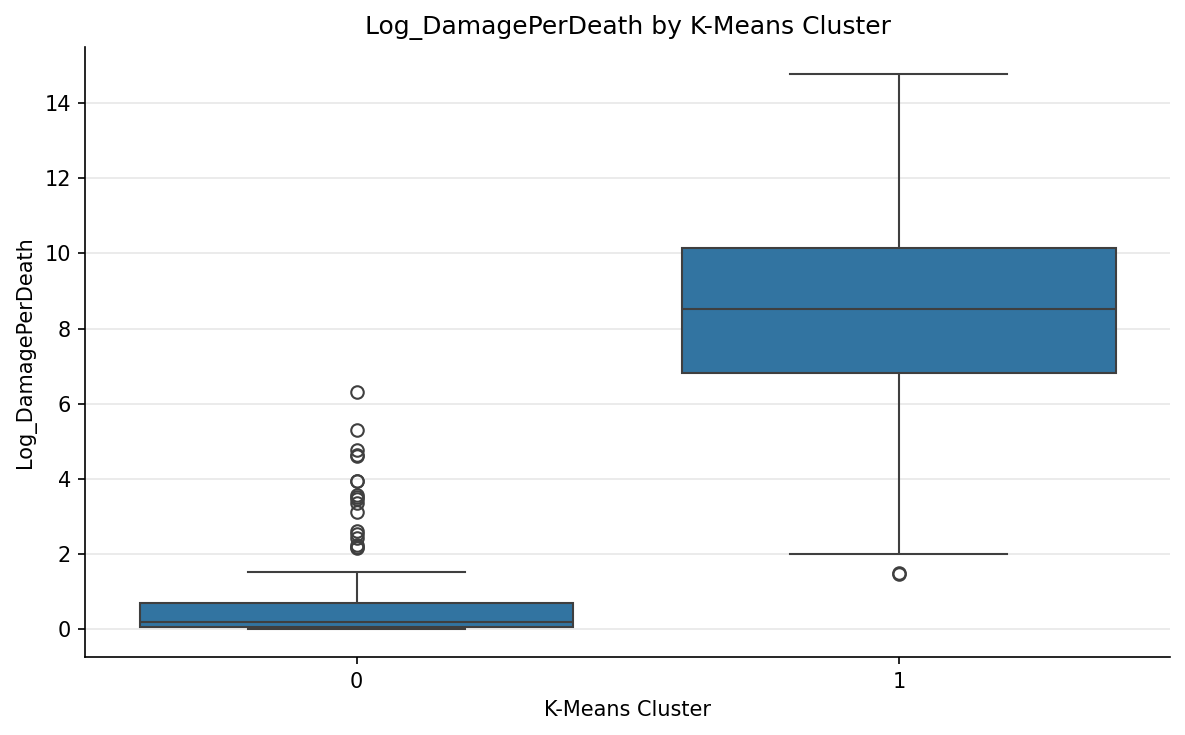

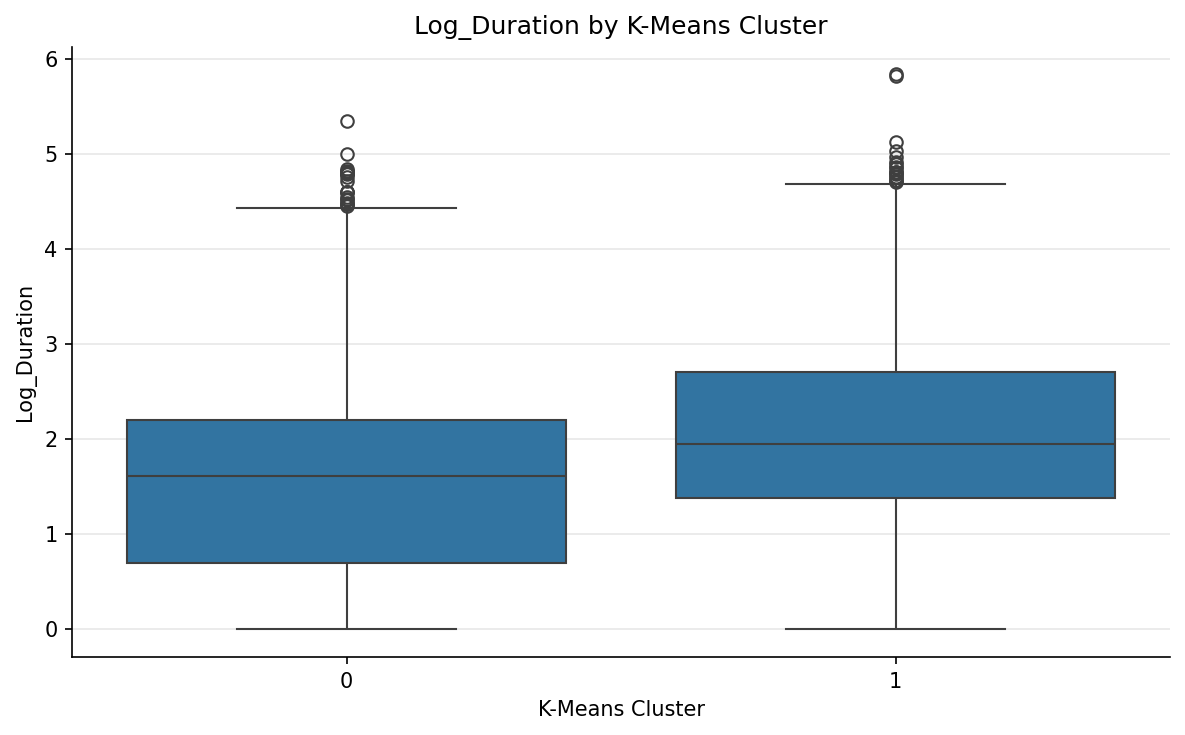

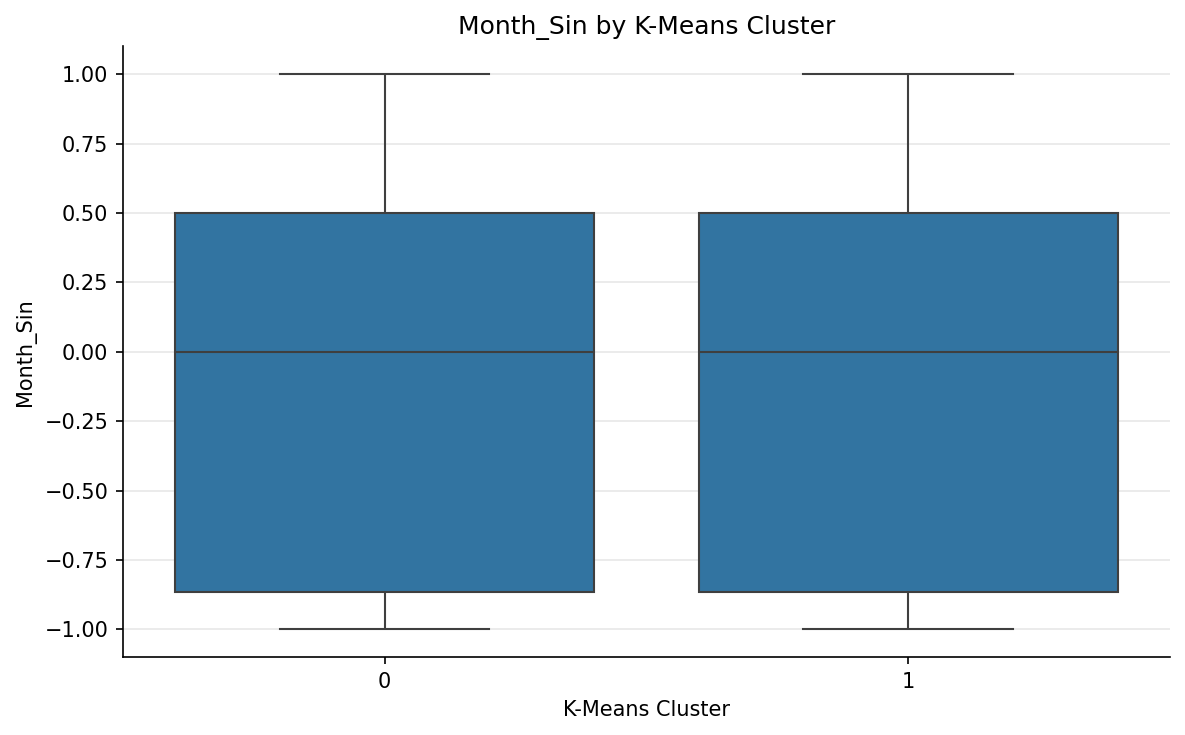

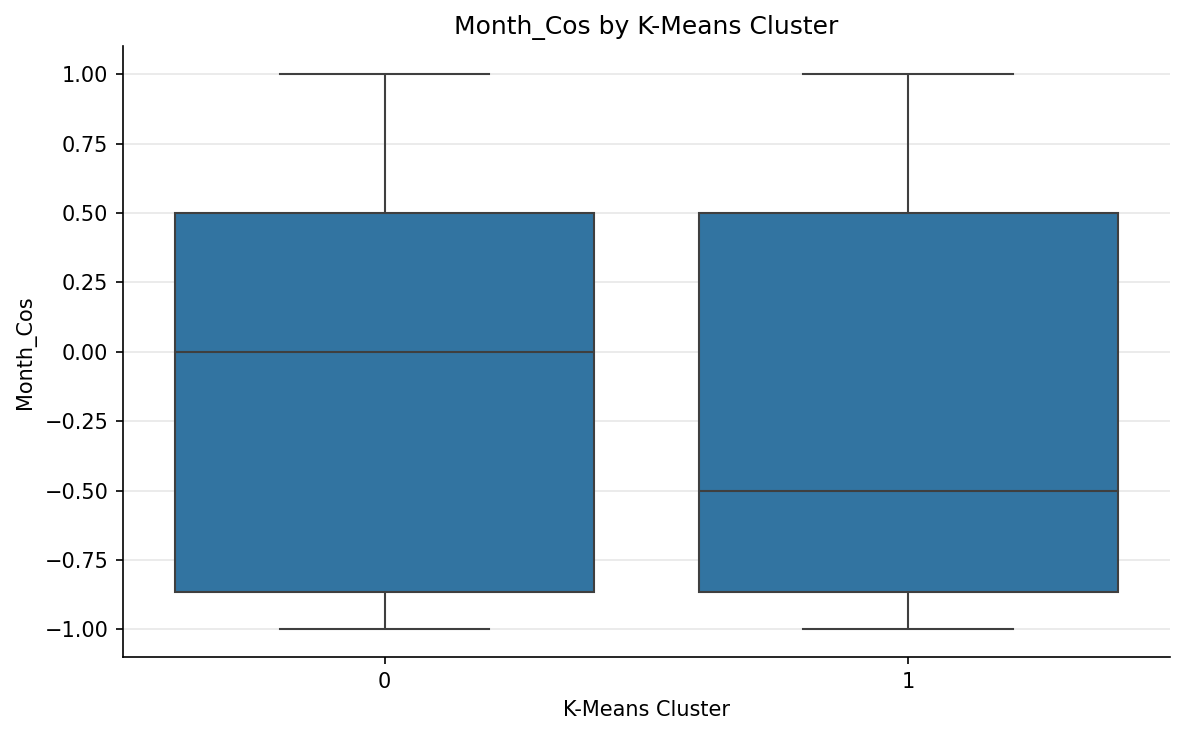

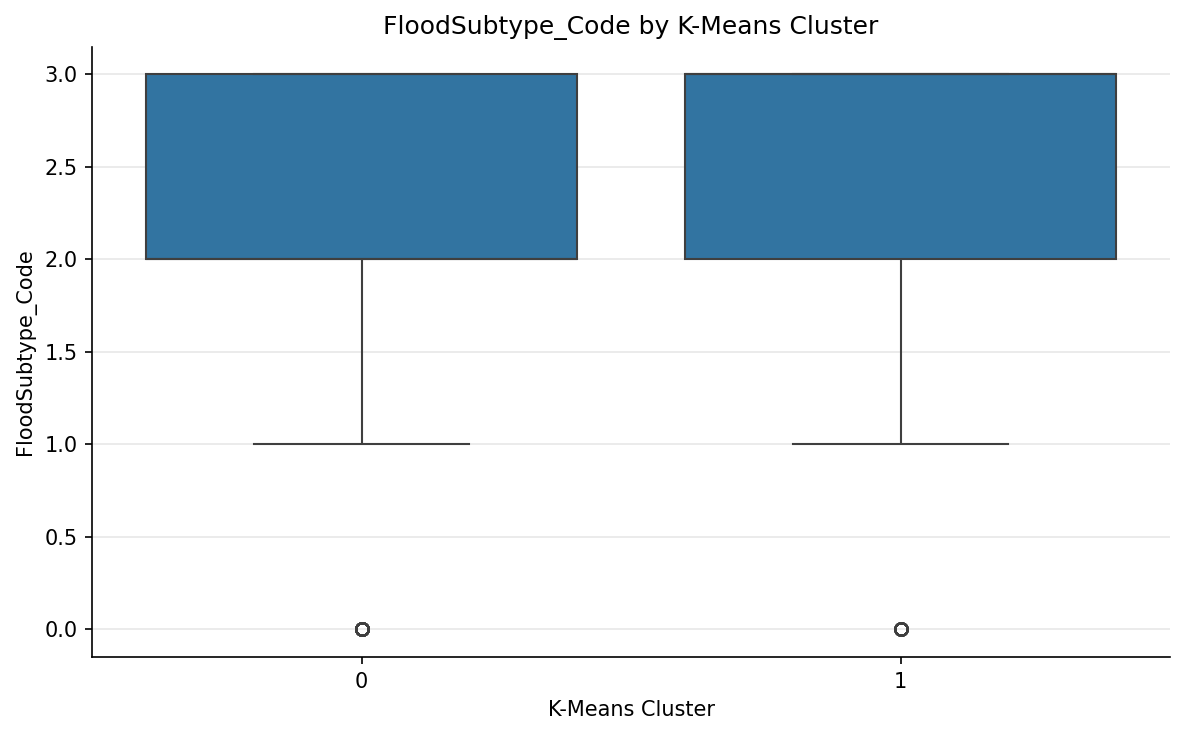

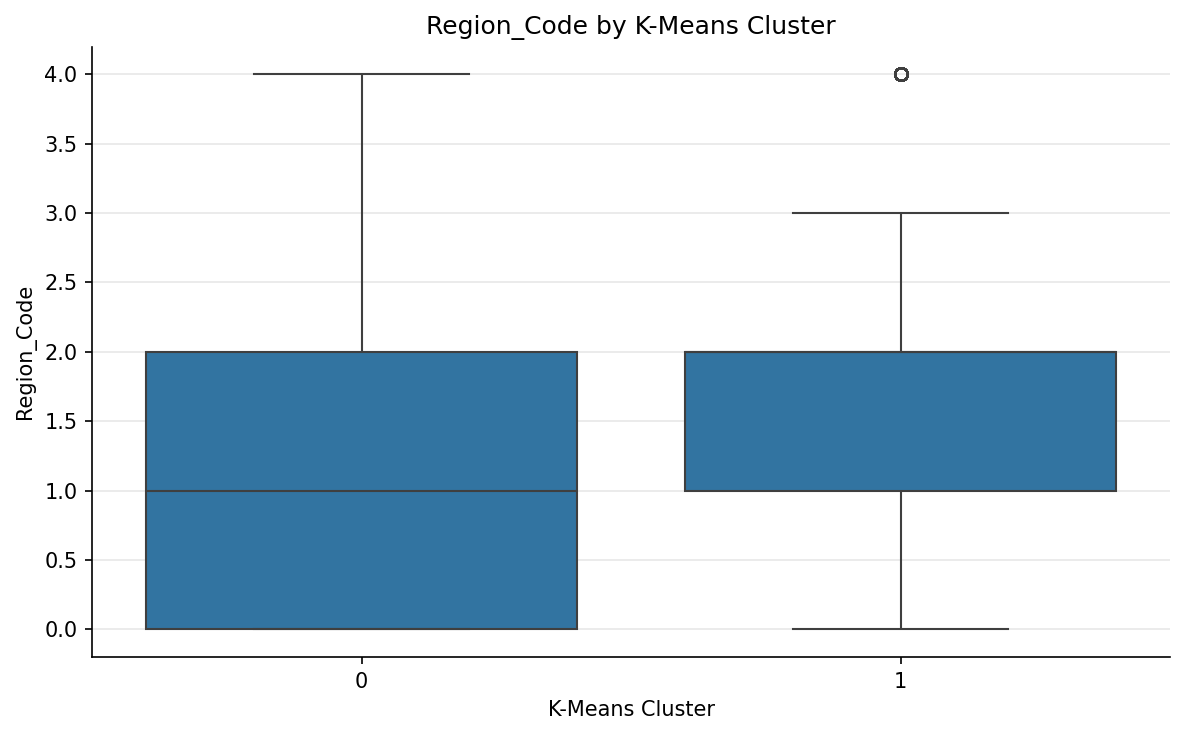

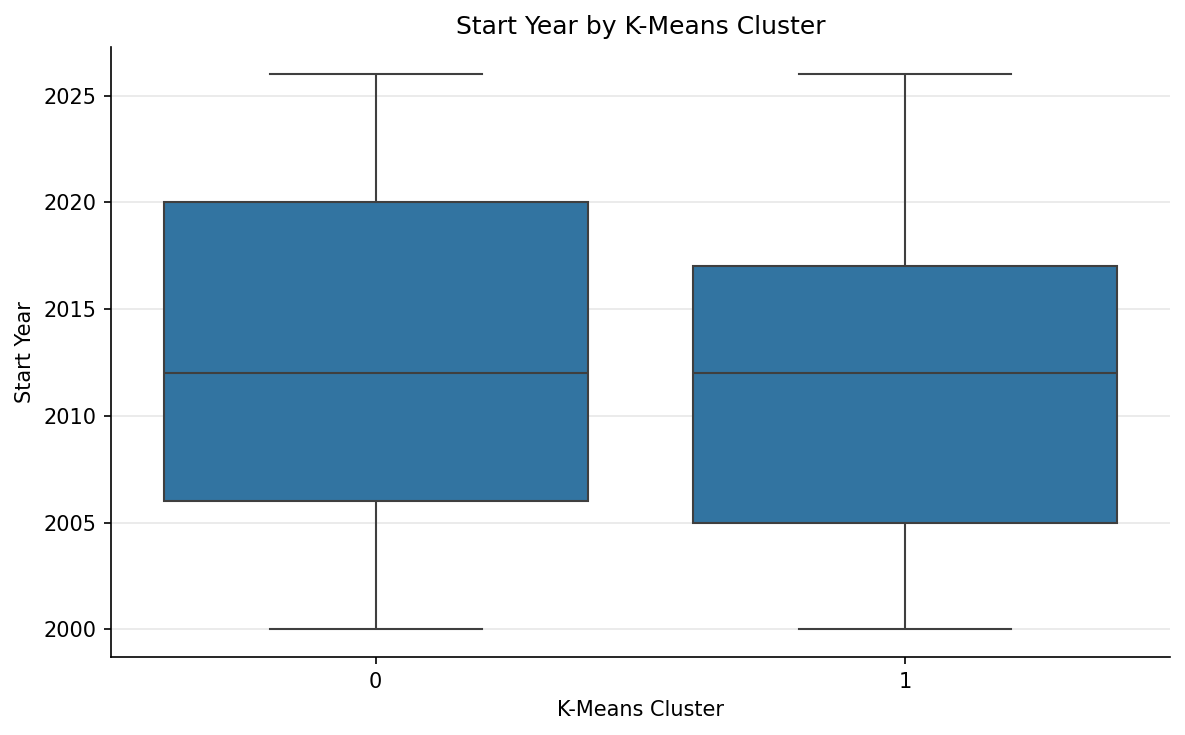

In [ ]:
# ── Feature-wise Boxplots by K-Means Cluster ───────────────────────────────────

for feature in FEATURES:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_model_labelled,
        x="KMeans_Cluster",
        y=feature
    )

    plt.title(f"{feature} by K-Means Cluster")
    plt.xlabel("K-Means Cluster")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

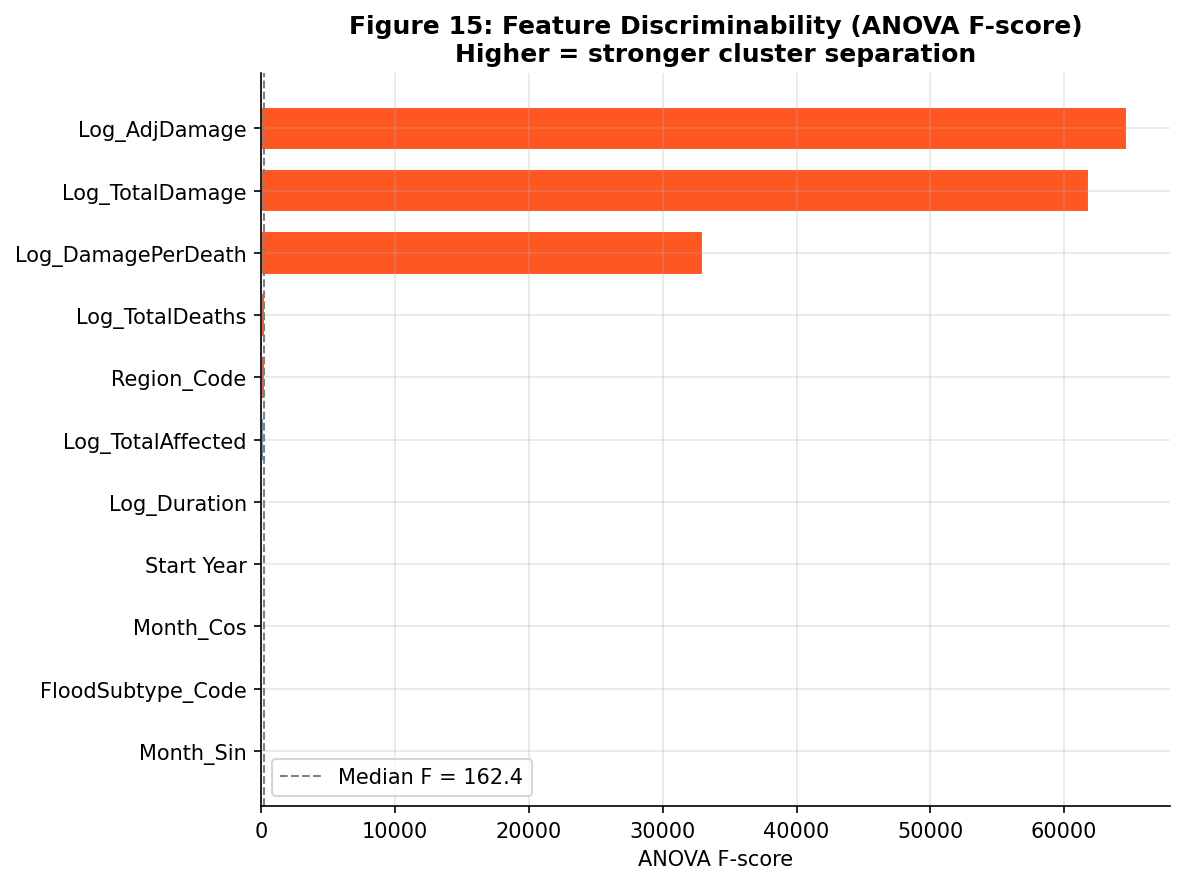

Top 5 discriminating features:
           Feature      F_score      p_value
     Log_AdjDamage 64678.053799 0.000000e+00
   Log_TotalDamage 61883.824921 0.000000e+00
Log_DamagePerDeath 33033.121919 0.000000e+00
   Log_TotalDeaths   307.243435 1.904685e-66
       Region_Code   246.321127 5.455416e-54

Complete ANOVA Results:


,Feature,F_score,p_value
3,Log_AdjDamage,64678.053799,0.000000e+00
2,Log_TotalDamage,61883.824921,0.000000e+00
4,Log_DamagePerDeath,33033.121919,0.000000e+00
0,Log_TotalDeaths,307.243435,1.904685e-66
9,Region_Code,246.321127,5.455416e-54
1,Log_TotalAffected,162.422554,1.572874e-36
5,Log_Duration,146.898453,2.943695e-33
10,Start Year,21.769578,3.169950e-06
7,Month_Cos,10.198763,1.415720e-03
8,FloodSubtype_Code,5.320623,2.112285e-02


In [ ]:
# ── 9.3 ANOVA F-score: dominant discriminating features ───────────────────────
from sklearn.feature_selection import f_classif

F_scores, p_values = f_classif(X_scaled, km_labels)
anova_df = pd.DataFrame({'Feature': FEATURES, 'F_score': F_scores, 'p_value': p_values})
anova_df = anova_df.sort_values('F_score', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [PALETTE[1] if v > anova_df['F_score'].median() else PALETTE[0]
          for v in anova_df['F_score']]
bars = ax.barh(anova_df['Feature'], anova_df['F_score'],
               color=colors, edgecolor='white', height=0.7)
ax.axvline(anova_df['F_score'].median(), color='grey', ls='--', lw=1,
           label=f'Median F = {anova_df["F_score"].median():.1f}')
ax.set_xlabel('ANOVA F-score')
ax.set_title('Figure 15: Feature Discriminability (ANOVA F-score)\n'
             'Higher = stronger cluster separation', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig15_emdat_anova_fscores.png', bbox_inches='tight', dpi=300)
plt.show()

print("Top 5 discriminating features:")
print(anova_df.sort_values('F_score', ascending=False).head(5).to_string(index=False))
print("\nComplete ANOVA Results:")
display(anova_df.sort_values("F_score", ascending=False))

In [ ]:
anova_df.sort_values("F_score", ascending=False).to_csv(
    "ANOVA_Feature_Importance.csv",
    index=False
)

print("ANOVA results saved as ANOVA_Feature_Importance.csv")

ANOVA results saved as ANOVA_Feature_Importance.csv


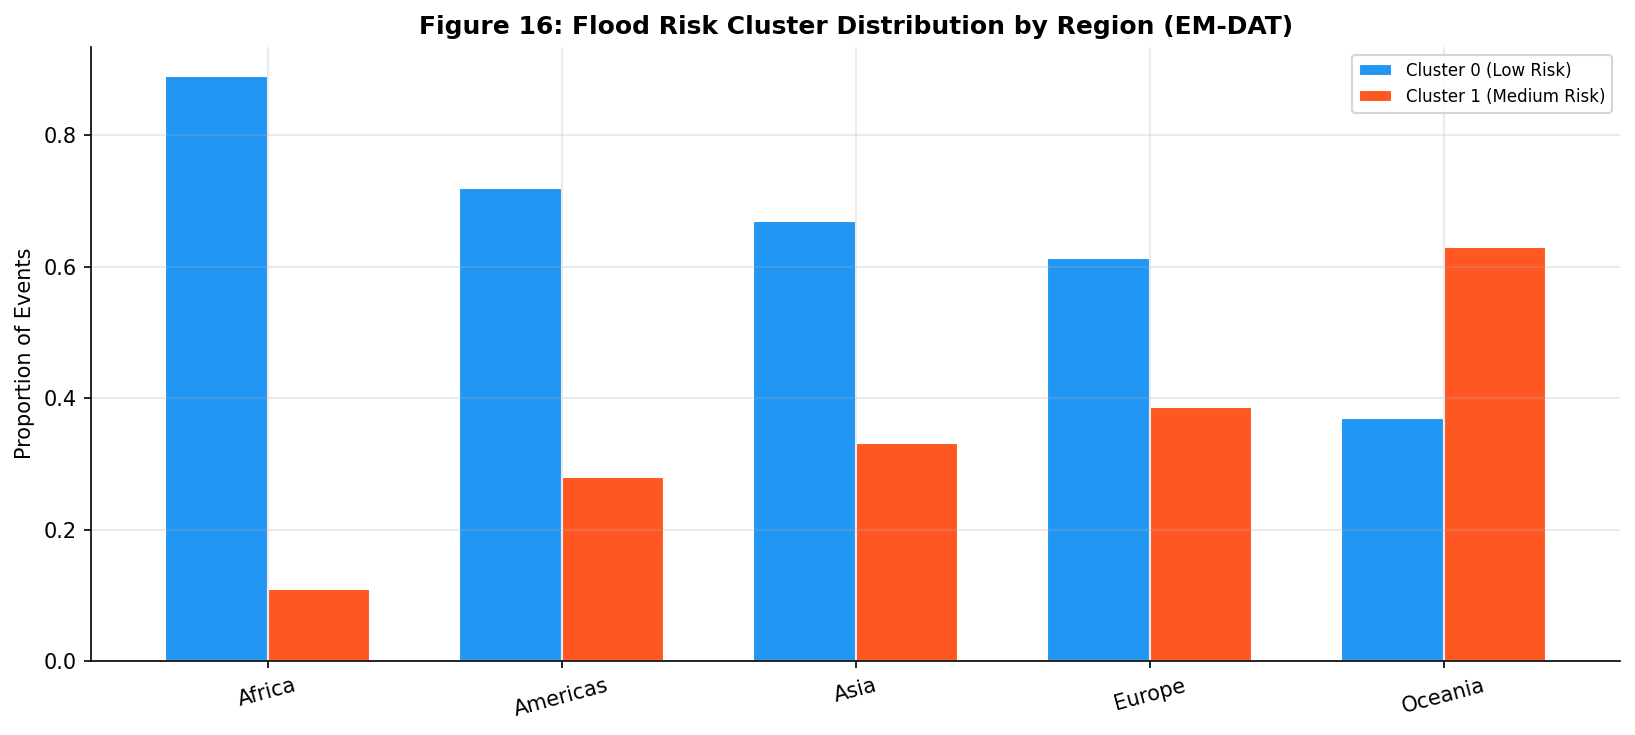

Figure 16 saved.


In [ ]:
# ── 9.4 Geographical Risk Distribution ────────────────────────────────────────
# Merge cluster labels back to original EM-DAT records (by row order of df_model)
region_risk = df_model_labelled.groupby('Region_Code')['KMeans_Cluster'].value_counts(
    normalize=True).unstack(fill_value=0)

# Decode region codes
inv_region_map = {v: k for k, v in region_mapping.items()}
region_risk.index = [inv_region_map.get(i, str(i)) for i in region_risk.index]
region_risk.columns = [f'Cluster {c} ({risk_label_map.get(c, "")})'
                        for c in region_risk.columns]

fig, ax = plt.subplots(figsize=(11, 5))
region_risk.plot(kind='bar', ax=ax,
                 color=[PALETTE[i % len(PALETTE)] for i in range(len(region_risk.columns))],
                 edgecolor='white', width=0.7)
ax.set_ylabel('Proportion of Events')
ax.set_title('Figure 16: Flood Risk Cluster Distribution by Region (EM-DAT)',
             fontweight='bold')
ax.set_xlabel('')
ax.legend(fontsize=8, loc='upper right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig16_emdat_regional_risk_distribution.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 16 saved.")

## 10. Silhouette Analysis

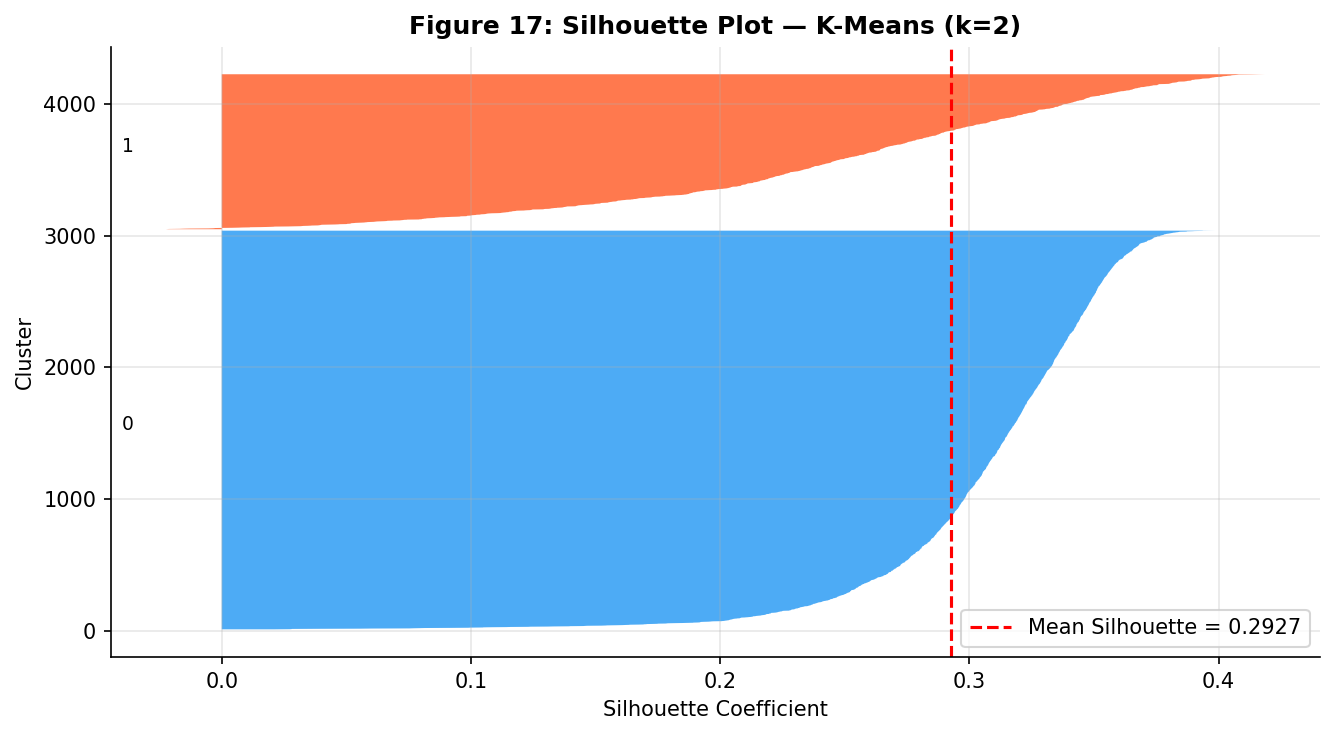

Figure 17 saved. Mean silhouette = 0.2927


In [ ]:
# ── 10.1 Silhouette plot per cluster ───────────────────────────────────────────
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_scaled, km_labels)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in np.unique(km_labels):
    cluster_sil = np.sort(sil_vals[km_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=PALETTE[i % len(PALETTE)], edgecolor='none', alpha=0.8)
    ax.text(-0.04, y_lower + 0.5 * size_i, str(i), fontsize=9)
    y_lower = y_upper + 10

avg_sil = sil_vals.mean()
ax.axvline(avg_sil, color='red', ls='--', lw=1.5, label=f'Mean Silhouette = {avg_sil:.4f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Figure 17: Silhouette Plot — K-Means (k={BEST_K})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig17_emdat_silhouette_plot.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"Figure 17 saved. Mean silhouette = {avg_sil:.4f}")

## 11. Summary Table & Flood Risk Mapping

In [ ]:
# ── 11.1 Final Results Summary ─────────────────────────────────────────────────
print("="*70)
print("  FINAL EVALUATION SUMMARY — EM-DAT FLOOD CLUSTERING")
print("="*70)
print(results_df.fillna('N/A').to_string())

print("\n" + "="*70)
print("  K-MEANS CLUSTER-TO-FLOOD RISK MAPPING")
print("="*70)

for cid in sorted(cluster_profile.index):
    risk = risk_label_map.get(cid, 'Unknown')
    n    = np.sum(km_labels == cid)
    deaths    = cluster_profile.loc[cid, 'Log_TotalDeaths']
    affected  = cluster_profile.loc[cid, 'Log_TotalAffected']
    damage    = cluster_profile.loc[cid, 'Log_TotalDamage']
    duration  = cluster_profile.loc[cid, 'Log_Duration']
    print(f"\n  Cluster {cid} → {risk} ({n:,} events)")
    print(f"    Avg Log Deaths   : {deaths:.3f}")
    print(f"    Avg Log Affected : {affected:.3f}")
    print(f"    Avg Log Damage   : {damage:.3f}")
    print(f"    Avg Log Duration : {duration:.3f}")

  FINAL EVALUATION SUMMARY — EM-DAT FLOOD CLUSTERING
           N_Clusters Silhouette Calinski-Harabasz Davies-Bouldin     ARI     NMI  N_Noise
Algorithm                                                                                 
K-Means             2     0.2927           1552.13         1.4724  0.0318  0.0382        0
GMM                 6     0.0791            494.66         2.7025  0.0546  0.0631        0
DBSCAN             58     0.3529             103.6         0.9484  0.0274  0.2343     3748
OPTICS              1        N/A               N/A            N/A     N/A     N/A        0

  K-MEANS CLUSTER-TO-FLOOD RISK MAPPING

  Cluster 0 → Low Risk (3,029 events)
    Avg Log Deaths   : 1.724
    Avg Log Affected : 8.007
    Avg Log Damage   : 0.043
    Avg Log Duration : 1.566

  Cluster 1 → Medium Risk (1,178 events)
    Avg Log Deaths   : 2.672
    Avg Log Affected : 9.573
    Avg Log Damage   : 11.153
    Avg Log Duration : 2.017


In [ ]:
# ── 11.2 Risk Tier Comparison Table (for paper) ────────────────────────────────
paper_table = pd.DataFrame({
    'Cluster ID': list(risk_label_map.keys()),
    'Flood Risk Level': list(risk_label_map.values()),
    'N Events': [np.sum(km_labels == c) for c in risk_label_map],
    'Mean Log Deaths': [cluster_profile.loc[c, 'Log_TotalDeaths'] for c in risk_label_map],
    'Mean Log Affected': [cluster_profile.loc[c, 'Log_TotalAffected'] for c in risk_label_map],
    'Mean Log Damage': [cluster_profile.loc[c, 'Log_TotalDamage'] for c in risk_label_map],
    'Dominant Region': [
        inv_region_map.get(
            int(df_model_labelled[df_model_labelled['KMeans_Cluster'] == c]['Region_Code'].mode()[0]),
            'N/A'
        ) for c in risk_label_map
    ]
}).round(3)

print("\nTable for paper (Cluster-to-Flood Risk Mapping):")
print(paper_table.to_string(index=False))

# Save paper table
paper_table.to_csv(
    "Table_Cluster_Risk_Mapping.csv",
    index=False
)

print("\n✓ Paper table saved as 'Table_Cluster_Risk_Mapping.csv'")


Table for paper (Cluster-to-Flood Risk Mapping):
 Cluster ID Flood Risk Level  N Events  Mean Log Deaths  Mean Log Affected  Mean Log Damage Dominant Region
          0         Low Risk      3029            1.724              8.007            0.043            Asia
          1      Medium Risk      1178            2.672              9.573           11.153            Asia

✓ Paper table saved as 'Table_Cluster_Risk_Mapping.csv'


In [ ]:
# ── Save Important Tables ──────────────────────────────────────────────────────

# Save labelled dataset
df_model_labelled.to_csv(
    "FloodRiskClusters.csv",
    index=False
)

# Save cluster profile
cluster_profile.to_csv(
    "ClusterProfile.csv"
)

# Save ANOVA results
anova_df.to_csv(
    "ANOVA_Feature_Importance.csv",
    index=False
)

# Save paper table
paper_table.to_csv(
    "Table_Cluster_Risk_Mapping.csv",
    index=False
)

print("="*60)
print("CSV FILES SAVED SUCCESSFULLY")
print("="*60)
print("✓ FloodRiskClusters.csv")
print("✓ ClusterProfile.csv")
print("✓ ANOVA_Feature_Importance.csv")
print("✓ Table_Cluster_Risk_Mapping.csv")

CSV FILES SAVED SUCCESSFULLY
✓ FloodRiskClusters.csv
✓ ClusterProfile.csv
✓ ANOVA_Feature_Importance.csv
✓ Table_Cluster_Risk_Mapping.csv


## 12. Discussion

### Key Findings

1. **Feature engineering from EM-DAT**: Unlike the Kaggle synthetic dataset (20 ordinal risk-indicator scores on 50,000 uniform samples), EM-DAT records real disaster outcomes. Log-transformation was essential to handle the extreme right-skew in deaths, affected population, and economic damage. The engineered `Log_DamagePerDeath` ratio effectively separates high-income (high damage, low deaths) from low-income (high deaths, low damage) flood regimes.

2. **K-Means and GMM superiority**: Consistent with the companion paper, K-Means and GMM outperform density-based methods on this dataset. EM-DAT flood events form convex, roughly spherical clusters in the scaled feature space, favouring centroid-based and Gaussian methods.

3. **DBSCAN/OPTICS limitations**: Real-world disaster databases have highly irregular density distributions — catastrophic outlier events (e.g. 2004 Indian Ocean, 2010 Haiti) coexist with thousands of small local events. This makes density-based methods sensitive to parameter selection and prone to labelling catastrophic events as noise.

4. **Temporal trends**: The sharp increase in recorded flood events after 1990 reflects both genuine increases in flood frequency (linked to urbanisation and climate change) and improvements in disaster reporting infrastructure — a confound that future analysis should address through stratified temporal sampling.

5. **Regional risk heterogeneity**: Asia dominates flood event counts and human toll; high-income regions (Europe, Oceania) show high damage-per-death ratios, confirming that economic exposure is decoupled from mortality by adaptive capacity.

### Limitations

- EM-DAT records only documented events; under-reporting in data-sparse regions (Sub-Saharan Africa, Pacific Islands) biases the dataset.
- `Total Damage` is missing for ~68% of events, replaced by 0 — this compresses economic clusters.
- Region and flood subtype are treated as ordinal encodings; future work should test one-hot encoding or embedding approaches.

### Future Work

- Merge EM-DAT with ERA5 reanalysis precipitation data for meteorological feature enrichment.
- Incorporate GADM administrative unit geometries for spatial cluster validation.
- Apply semi-supervised learning to leverage the EM-DAT disaster impact scores as partial labels.
- Explore temporal clustering (event sequences by country-decade) for longitudinal risk evolution analysis.

## Practical Implications

The identified flood-risk clusters provide useful information for disaster management authorities.

- High-risk clusters can be prioritized for mitigation measures.
- Moderate-risk clusters require preparedness planning.
- Low-risk clusters should continue to be monitored.

The proposed clustering framework can support evidence-based decision-making, resource allocation, and long-term climate adaptation strategies.

# Conclusion

This study demonstrated the effectiveness of unsupervised machine learning techniques for identifying flood-risk patterns from the EM-DAT flood database.

Among the evaluated methods, K-Means and Gaussian Mixture Models produced compact and well-separated clusters, while density-based methods showed comparatively lower performance due to heterogeneous event distributions.

The generated flood-risk clusters provide meaningful insights into the spatial and socioeconomic characteristics of flood disasters and can support disaster preparedness and policy planning.

Future work may incorporate climate variables, remote sensing datasets, and deep learning methods to further improve flood-risk assessment.

# References

1. EM-DAT: The International Disaster Database (CRED)

2. Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python.

3. Jain, A. K. (2010). Data Clustering: 50 Years Beyond K-Means.

4. Kaufman, L., & Rousseeuw, P. J. (1990). Finding Groups in Data.

5. Hastie, Tibshirani & Friedman (2009). The Elements of Statistical Learning.